In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import subprocess
import os
from scipy.stats import chi2_contingency
from datetime import timedelta

from etl.customer import aggregate_customer
from etl.subsidy import report_customer_conversion_by_subsidy_issue_status, report_customer_metrics_by_subsidy_issue_status
from etl.subsidy import visualize_conversion_by_subsidy_issues, report_customer_subsidy_issues_by_product
from etl.subsidy import visualize_customer_subsidy_issues_by_product, visualize_policy_suspension_impact
from etl.price import visualize_conversion_by_price_sweet_spots, visualize_conversion_by_price_sweet_spots_variant
from etl.price import report_product_conversion_by_price_quartile, visualize_conversion_by_equipment_category_price
from etl.price import visualise_conversion_by_brand_price, show_two_panel_conversion_by_brand_price
from etl.price import visualize_conversion_by_equipment_type_brand_price, show_conversion_by_price_dashboard, show_product_type_price_conversion_heatmap
from etl.season import visualize_conversion_by_season, visualize_regional_seasonality
from etl.period import visualize_conversion_by_year, report_best_and_worst_months, show_conversion_by_price_over_time, overlay_all_years_on_one_plot
from etl.period import visualize_conversion_by_prices_sweet_spot_shift, visualize_decision_times, show_decision_time_dashboard
from etl.product import visualise_heat_pump_performance, show_product_type_by_brand_heatmap, show_product_type_by_agency_heatmap, show_brand_by_product_type_heatmap


import warnings
warnings.filterwarnings('ignore')

df_clean = pd.read_csv('cleaned_quote_data.csv')
df_clean['dt_creation_devis'] = pd.to_datetime(df_clean['dt_creation_devis'])
print(f"Loaded data: {len(df_clean):,} quotes from {df_clean['numero_compte'].nunique():,} customers")

Loaded data: 37,008 quotes from 25,716 customers


In [2]:
#customers = aggregate_customer(df_clean)

In [3]:
all_customers = pd.read_csv('customer_master_data.csv')

In [4]:
# Method 1: Using year column
customers_2025 = all_customers[all_customers['year'] == 2025]

# Method 2: Using period column
customers_2025 = all_customers[all_customers['period'] == '2025']

# Method 3: Using date range
customers_2025 = all_customers[
    (all_customers['first_quote_date'] >= '2025-01-01') & 
    (all_customers['first_quote_date'] <= '2025-12-31')
]

print(f"2025 customers: {len(customers_2025):,}")

2025 customers: 9,944


In [5]:
customers = customers_2025


Customer conversion by subsidy issue status:

                   conversion_rate  customer_count  converted_count
had_subsidy_issue                                                  
False                     0.344591            7432           2561.0
True                      0.445462            2512           1119.0

Chi-square p-value: 1.741976e-19
Statistically significant: YES

Conversion without issues: 34.46%
Conversion with issues: 44.55%
Difference: 10.1 percentage points
Customer-level finding: +10.1 points

Customer characteristics by subsidy issue status

Metric comparison:

total_quotes:
  No issues: 1.37
  With issues: 1.54
  Ratio: 1.12x

avg_quote_amount:
  No issues: 5824.46
  With issues: 9681.25
  Ratio: 1.66x

max_quote_amount:
  No issues: 6196.97
  With issues: 10553.75
  Ratio: 1.70x

customer_duration_days:
  No issues: 6.85
  With issues: 9.40
  Ratio: 1.37x

price_range:
  No issues: 819.22
  With issues: 1660.17
  Ratio: 2.03x

multiple_quotes:
  No issues: 0.

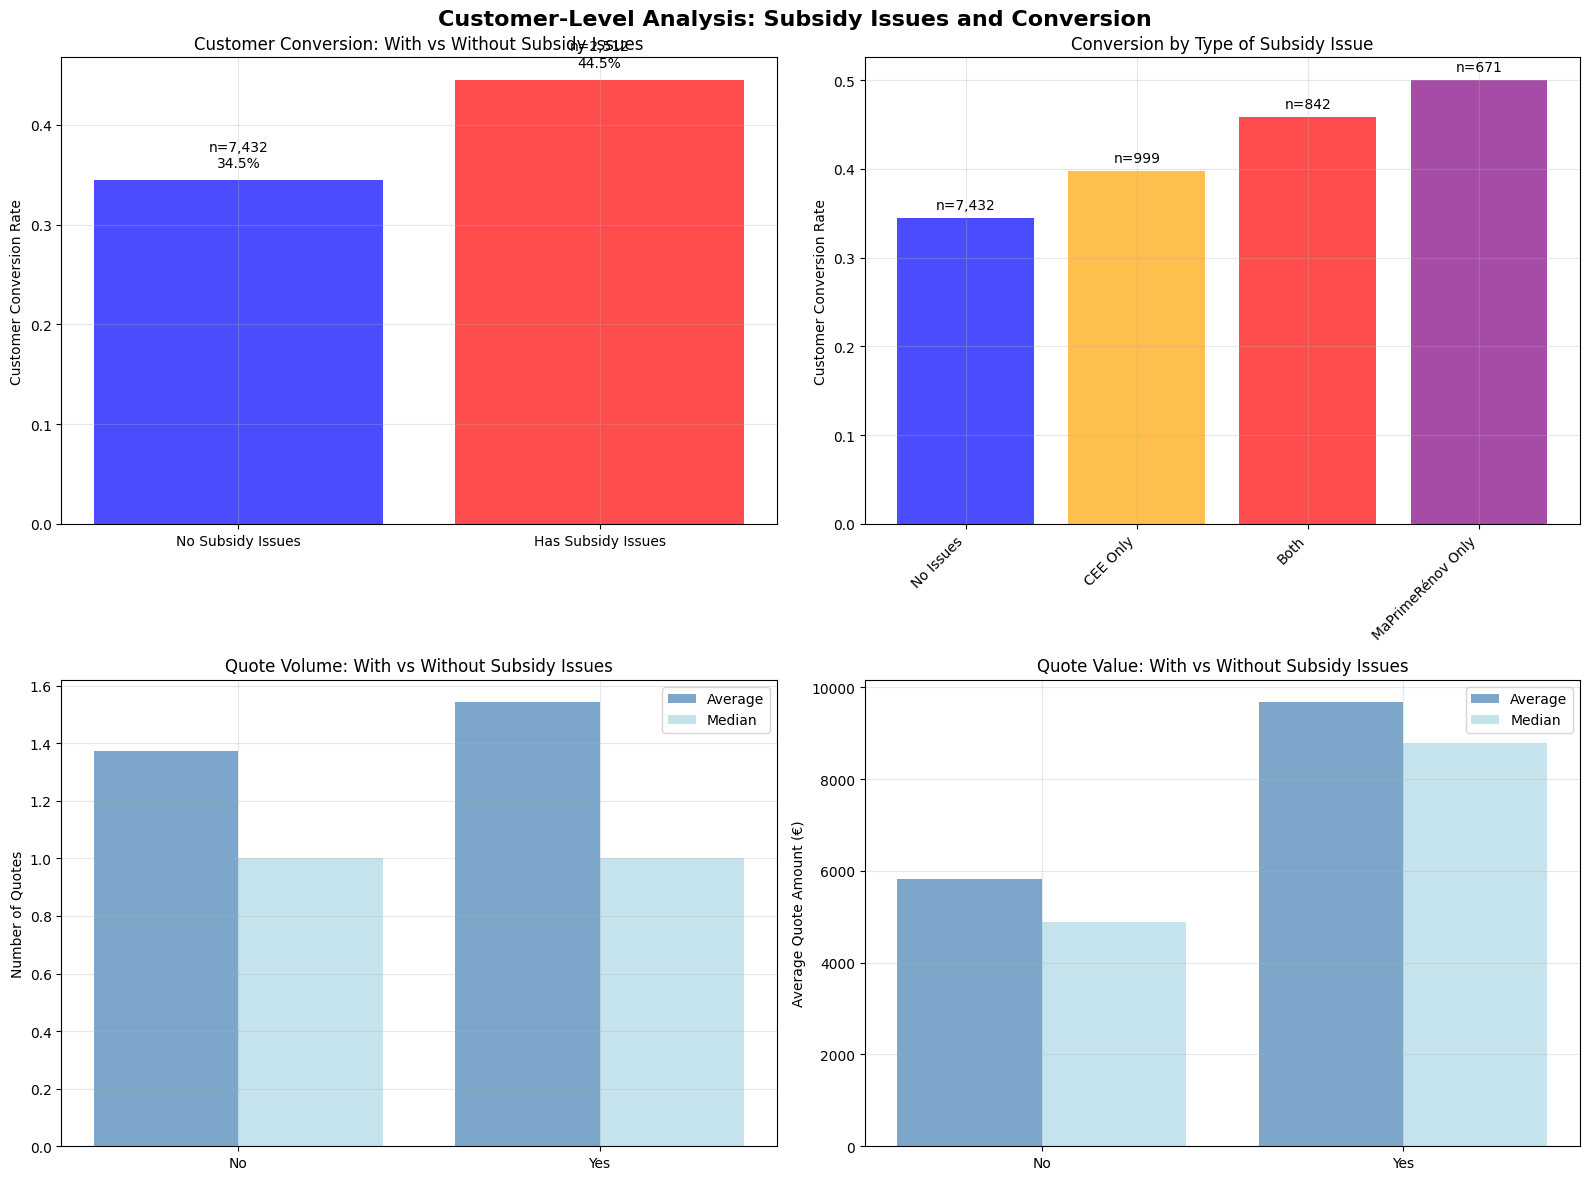


Policy Suspension Impact

Analyzing 9,602 customers
Price range: €1,332 to €27,121
Median price: €6,191
Unique values in during_suspension: [False  True]

Conversion during subsidy suspensions:
                       mean  count
Normal Periods     0.374845   7259
During Suspension  0.358942   2343

Suspension impact p-value: 0.1735
Statistically significant: NO

Product mix during suspensions:
main_equipment_category    AC  Boiler  Heat Pump  Other  Stove  Unknown
during_suspension                                                      
False                    19.5    33.4       16.4    8.6   21.9      0.2
True                     44.3    24.6        9.4    6.2   15.5      0.0


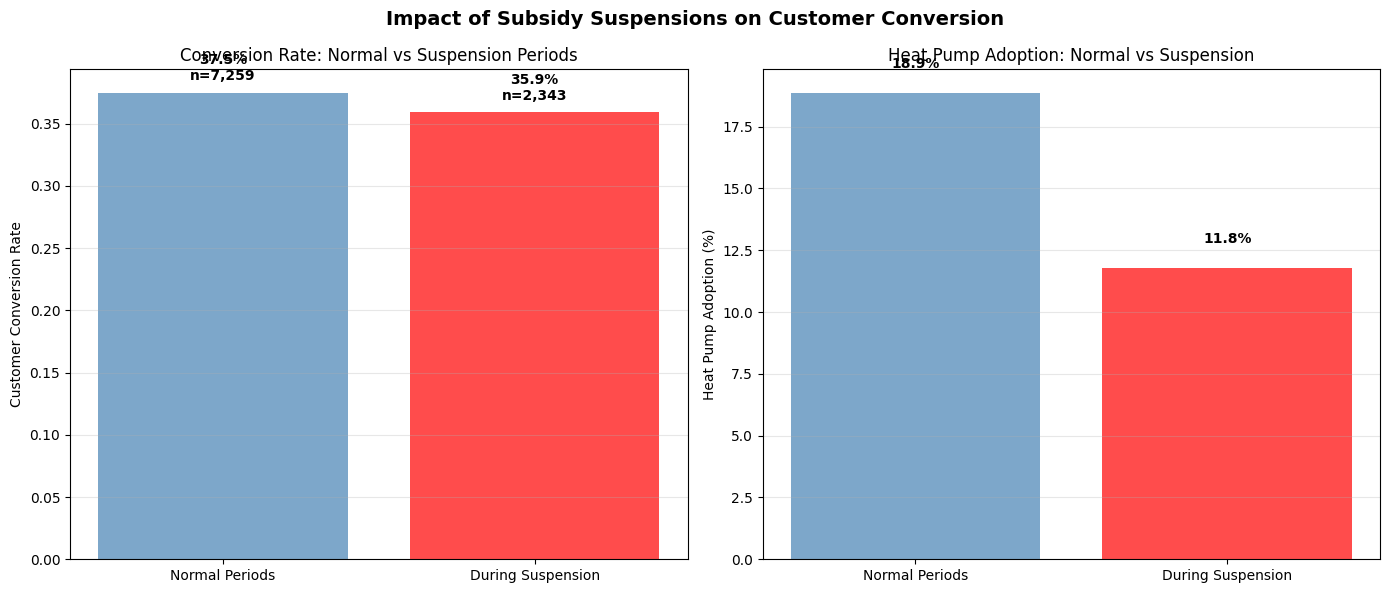

Unique values in main_product_family:
main_product_family
Chaudière                           3065
Climatisation                       2438
Poêle                               2027
Pompe à chaleur                     1362
ECS : Chauffe-eau ou adoucisseur     471
Photovoltaïque                       216
Appareil hybride                     122
Autres                                79
Plomberie Sanitaire                   57
Emetteur de chauffage  ou chappe      47
Produit VMC                           37
Unknown                               16
Fumisterie                             7
Name: count, dtype: int64

Top products:
main_product_family
Chaudière                           3065
Climatisation                       2438
Poêle                               2027
Pompe à chaleur                     1362
ECS : Chauffe-eau ou adoucisseur     471
Photovoltaïque                       216
Appareil hybride                     122
Autres                                79
Plomberie Sanitaire 

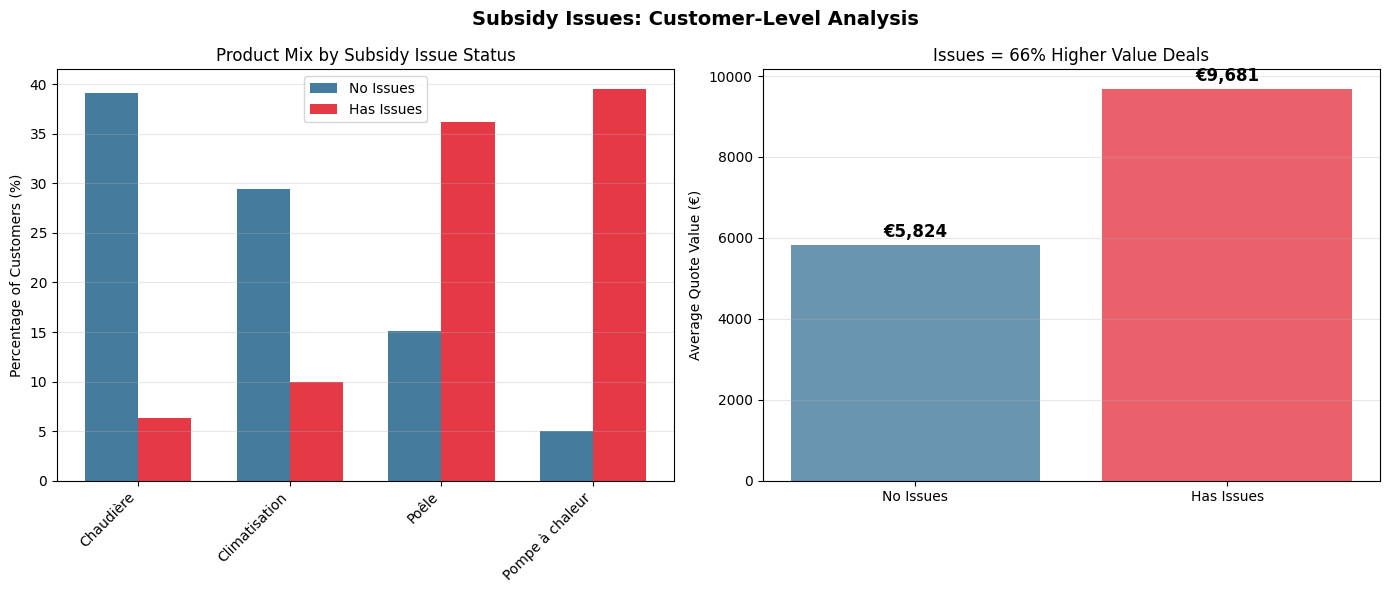


Threshold effect

Analyzing 9,602 customers
Price range: €1,332 to €27,121
Median price: €6,191


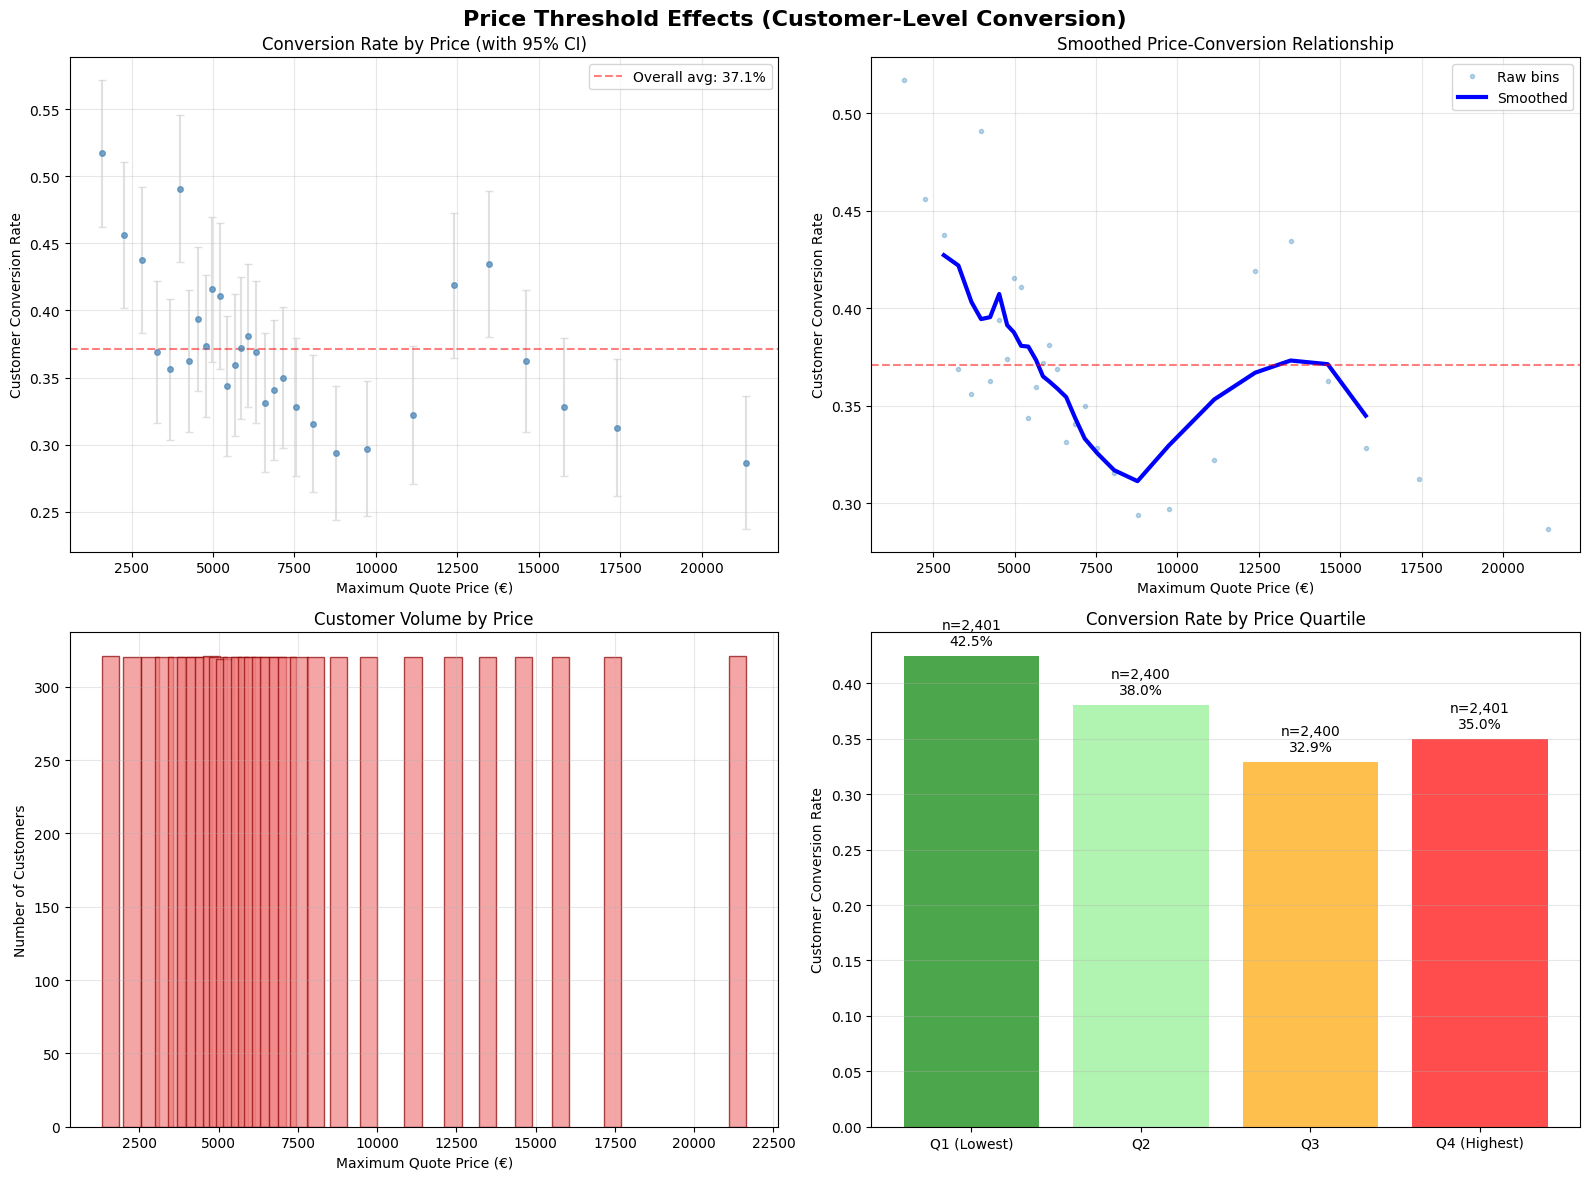


THRESHOLD EFFECT: KEY FINDINGS

Conversion by Price Quartile:
  Q1 (Lowest): 42.5% (n=2,401)
  Q2: 38.0% (n=2,400)
  Q3: 32.9% (n=2,400)
  Q4 (Highest): 35.0% (n=2,401)

Difference between lowest and highest quartile: 7.5 percentage points

Sweet spots (above-average conversion):
  €1,595: 51.7% (n=321)
  €2,261: 45.6% (n=320)
  €2,830: 43.8% (n=320)
  €3,972: 49.1% (n=320)
  €4,529: 39.4% (n=320)
  €4,774: 37.4% (n=321)
  €4,982: 41.6% (n=320)
  €5,201: 41.1% (n=319)
  €5,872: 37.2% (n=320)
  €6,059: 38.1% (n=320)
  €12,387: 41.9% (n=320)
  €13,476: 43.4% (n=320)

Analyzing 9,602 customers
Price range: €1,332 to €27,121
Median price: €6,191

Product mix by price quartile

Product distribution by price quartile (%):
main_equipment_category    AC  Boiler  Heat Pump  Other  Stove  Unknown
price_quartile                                                         
Q1_Low                   31.9    38.8        0.6   21.3    7.3      0.2
Q2_MidLow                20.1    37.7        0.6    2.3  

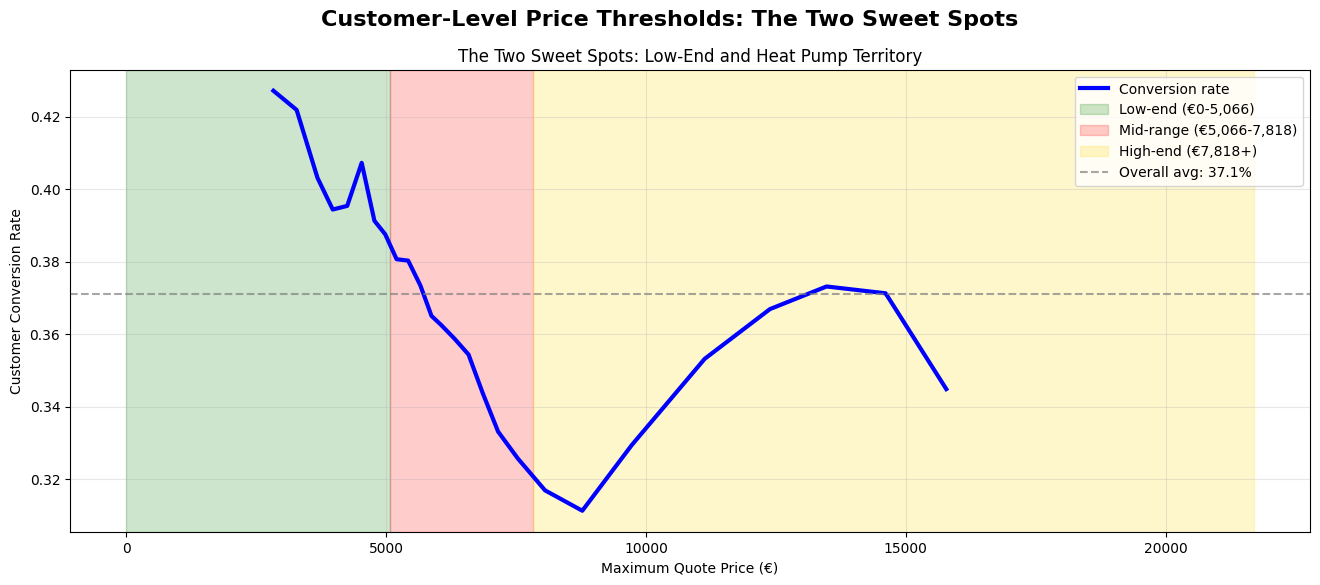

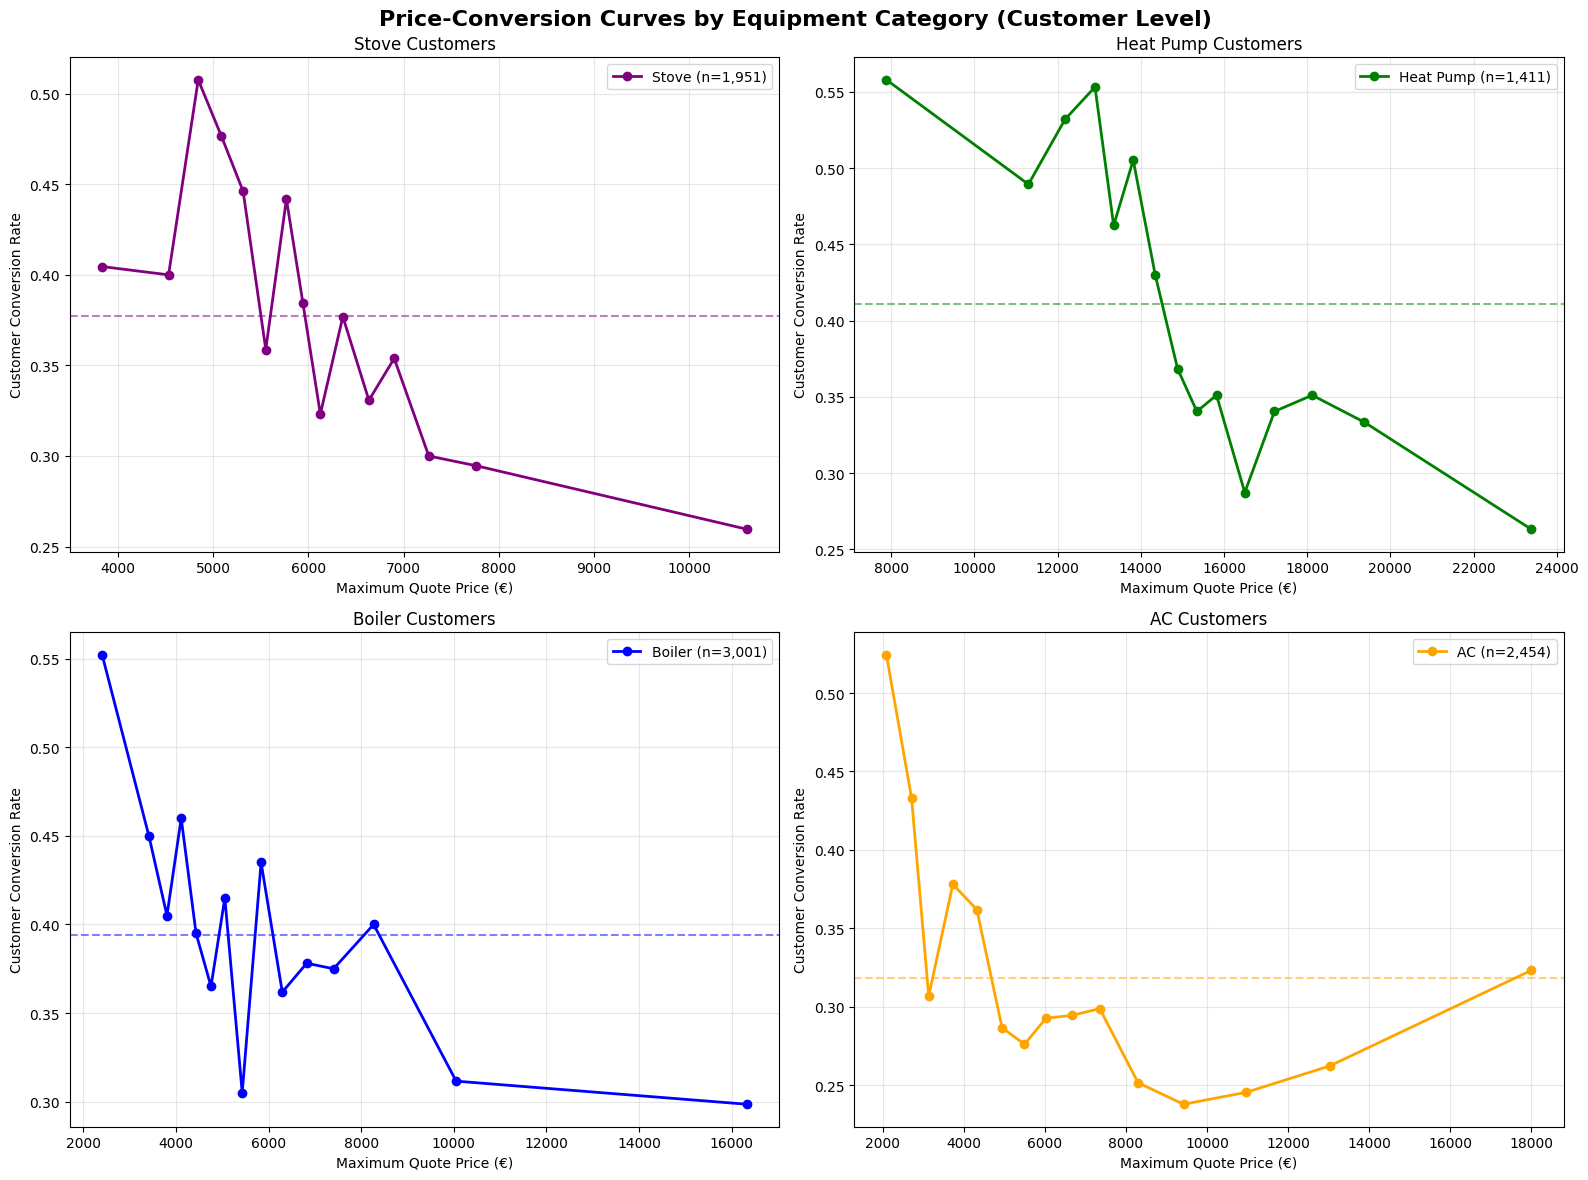


Conversion by Brand Price

Analyzing 9,602 customers
Price range: €1,332 to €27,121
Median price: €6,191
Top 8 brands: ['ATLANTIC', 'MITSUBISHI ELECTRIC', 'MCZ', 'E.L.M. LEBLANC', 'SAUNIER DUVAL', 'FRISQUET', 'DE DIETRICH', 'HITACHI']


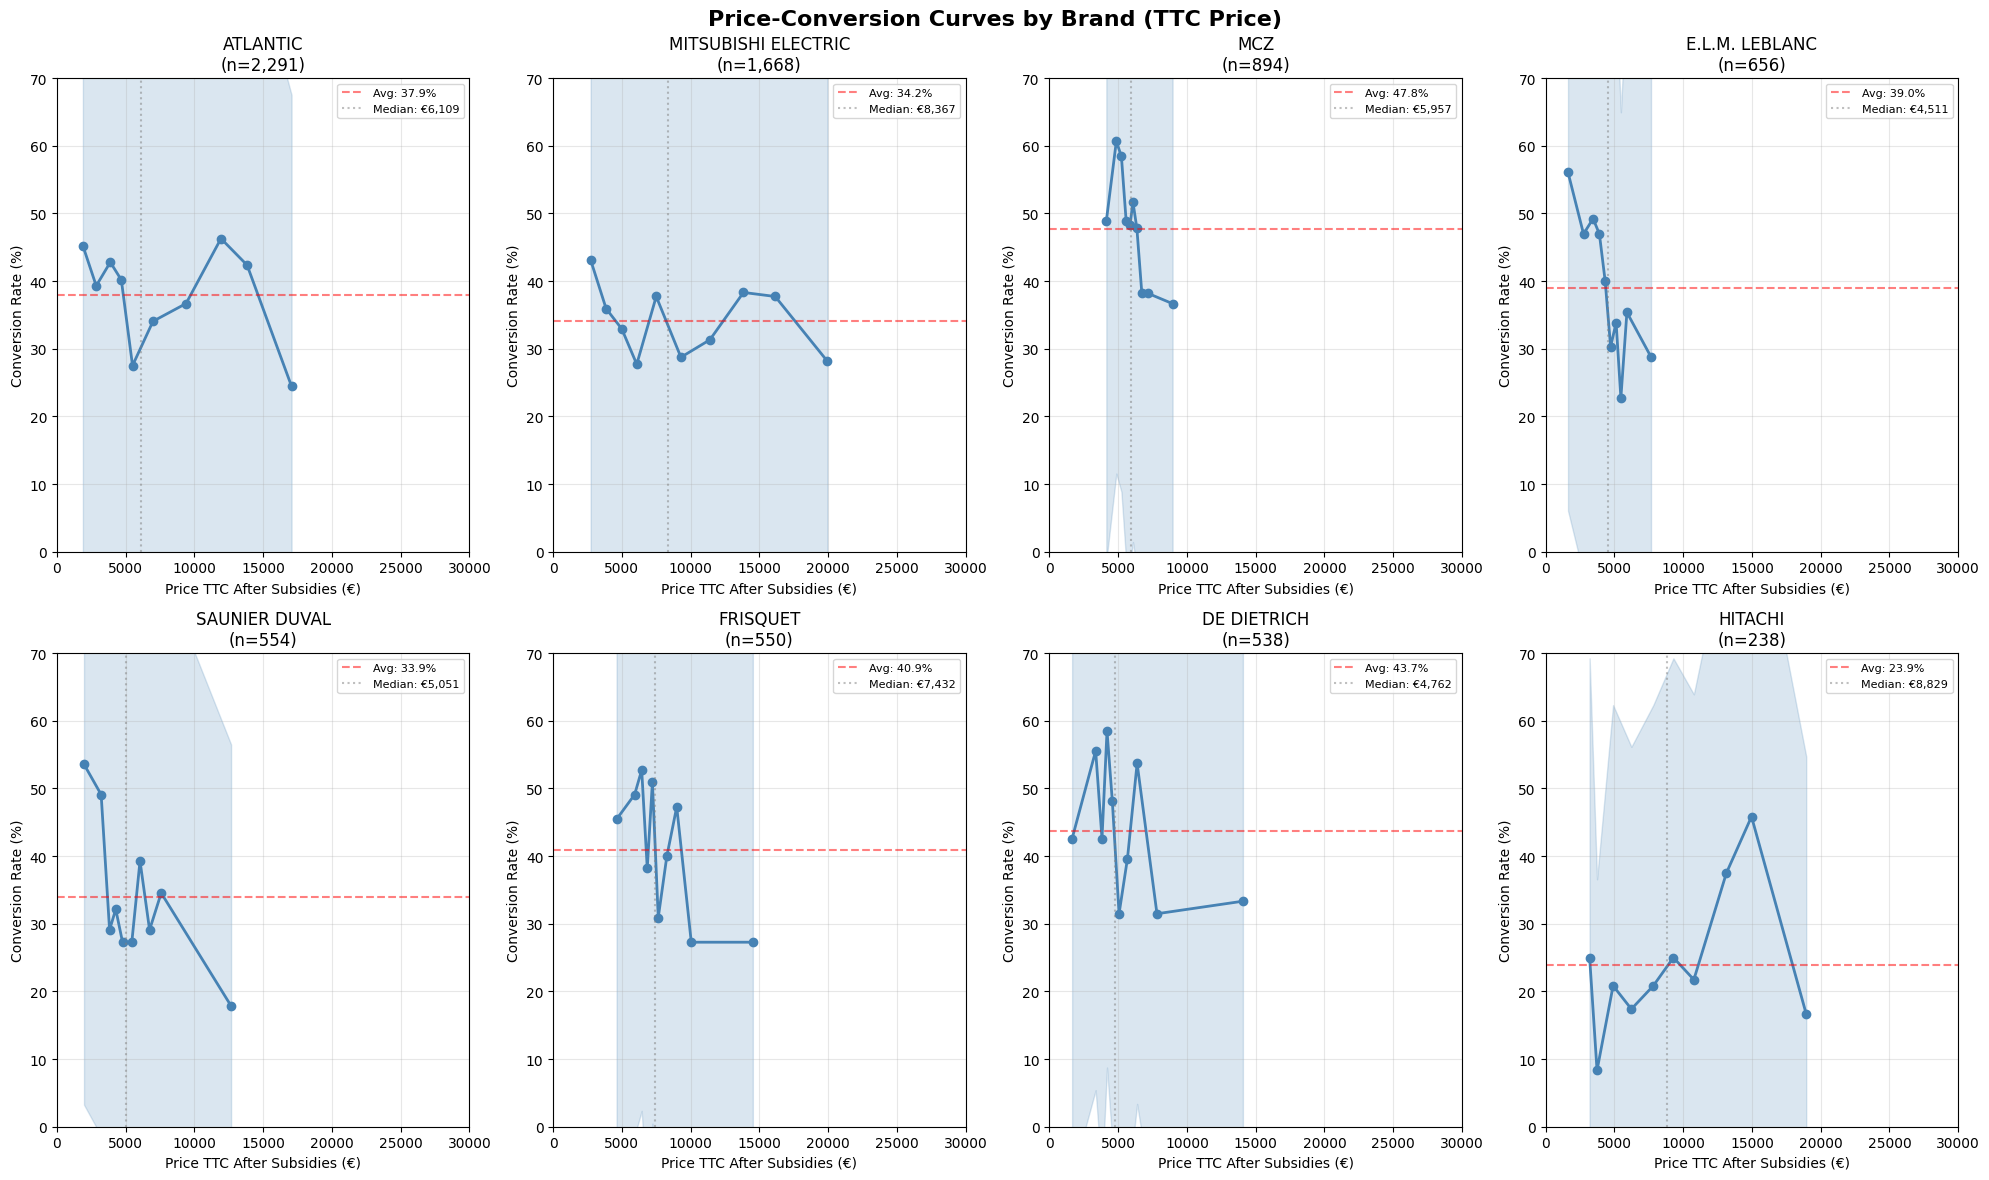


Analyzing 9,602 customers
Price range: €1,332 to €27,121
Median price: €6,191


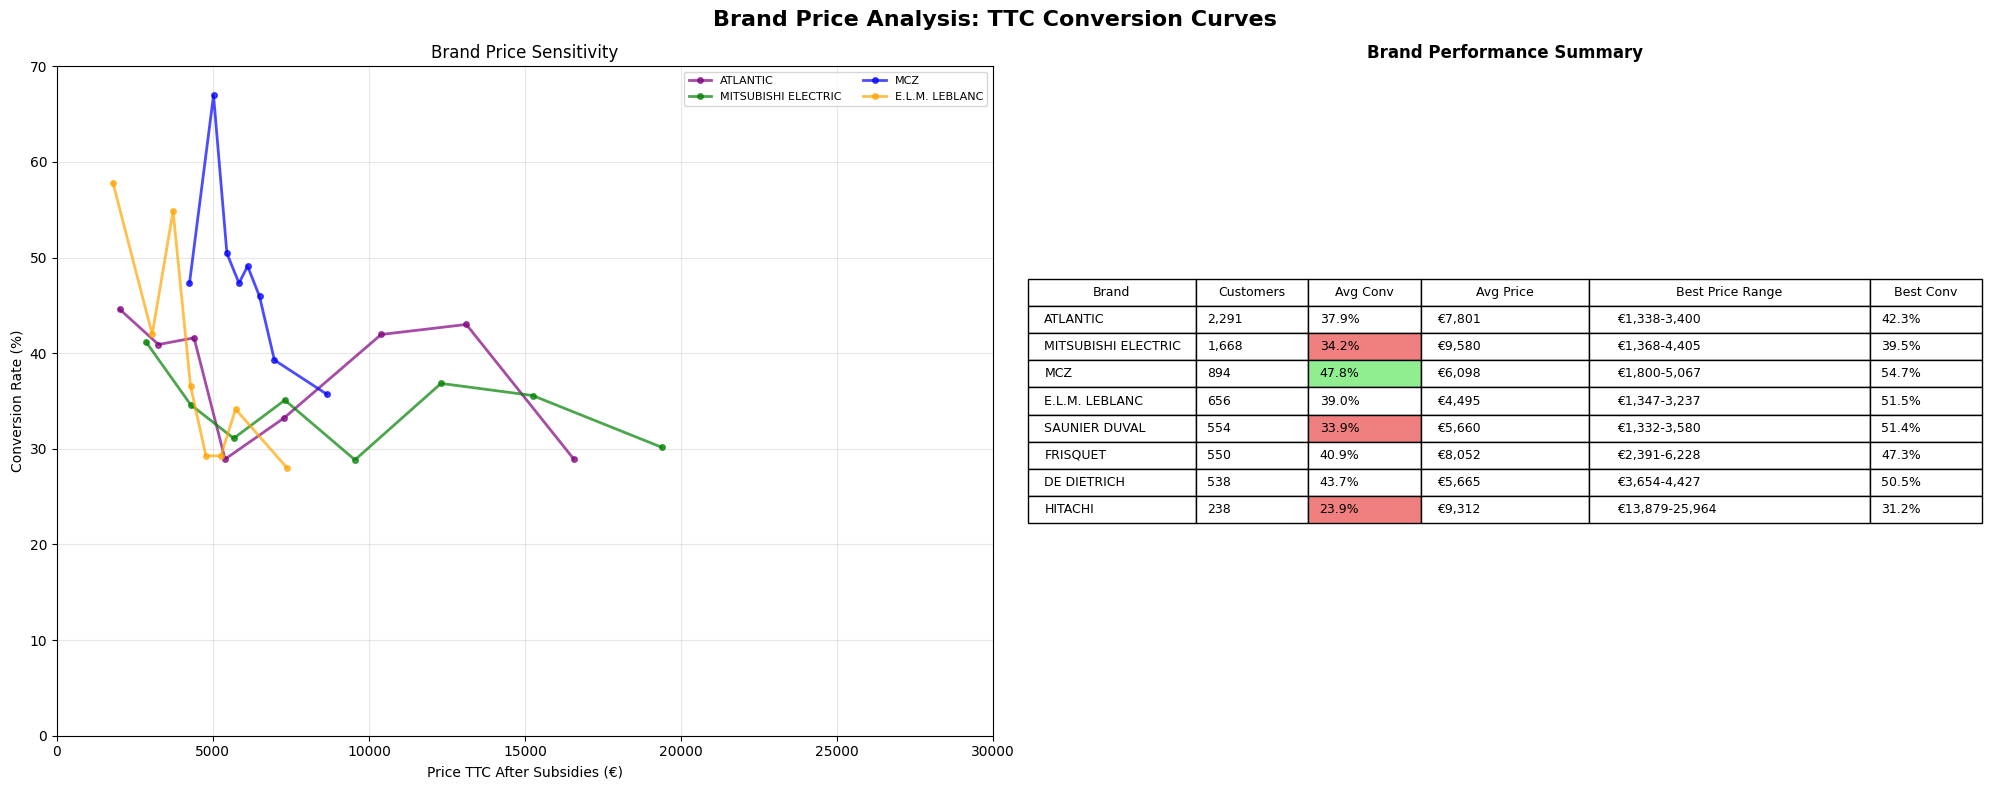


TTC Price-conversion curves: 4 equipment types, multiple brands per graph

Analyzing 9,602 customers
Price range: €1,332 to €27,121
Median price: €6,191

Heat Pump - Top brands: ['ATLANTIC', 'MITSUBISHI ELECTRIC', 'VIESSMANN', 'HITACHI']

Boiler - Top brands: ['E.L.M. LEBLANC', 'FRISQUET', 'ATLANTIC', 'SAUNIER DUVAL', 'DE DIETRICH', 'VIESSMANN']

Stove - Top brands: ['MCZ', 'JOLLY MEC', 'ORANIER', 'PALAZZETTI', 'DOVRE', 'Edilkamin']

AC - Top brands: ['MITSUBISHI ELECTRIC', 'ATLANTIC', 'HITACHI', 'BOSCH', 'DAIKIN']


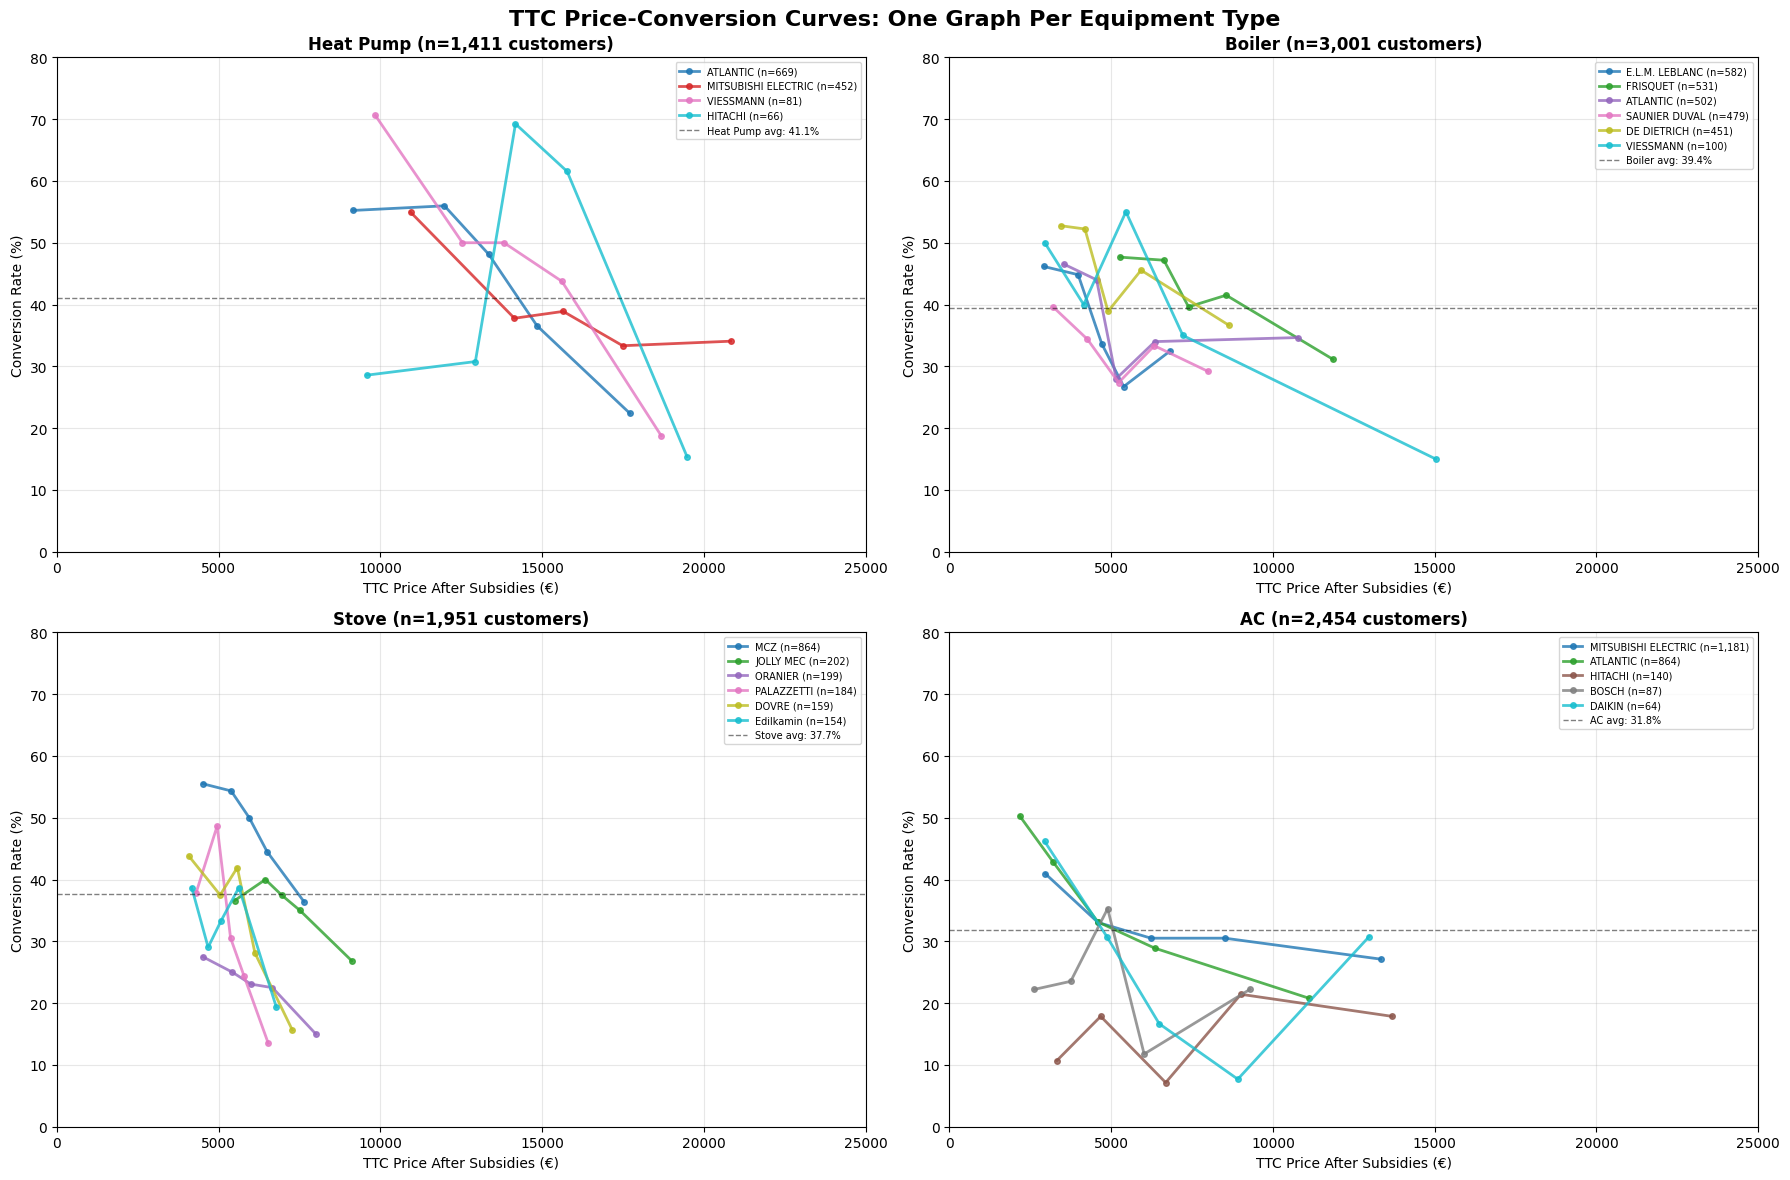


Seasonal Effects on Customer Conversion


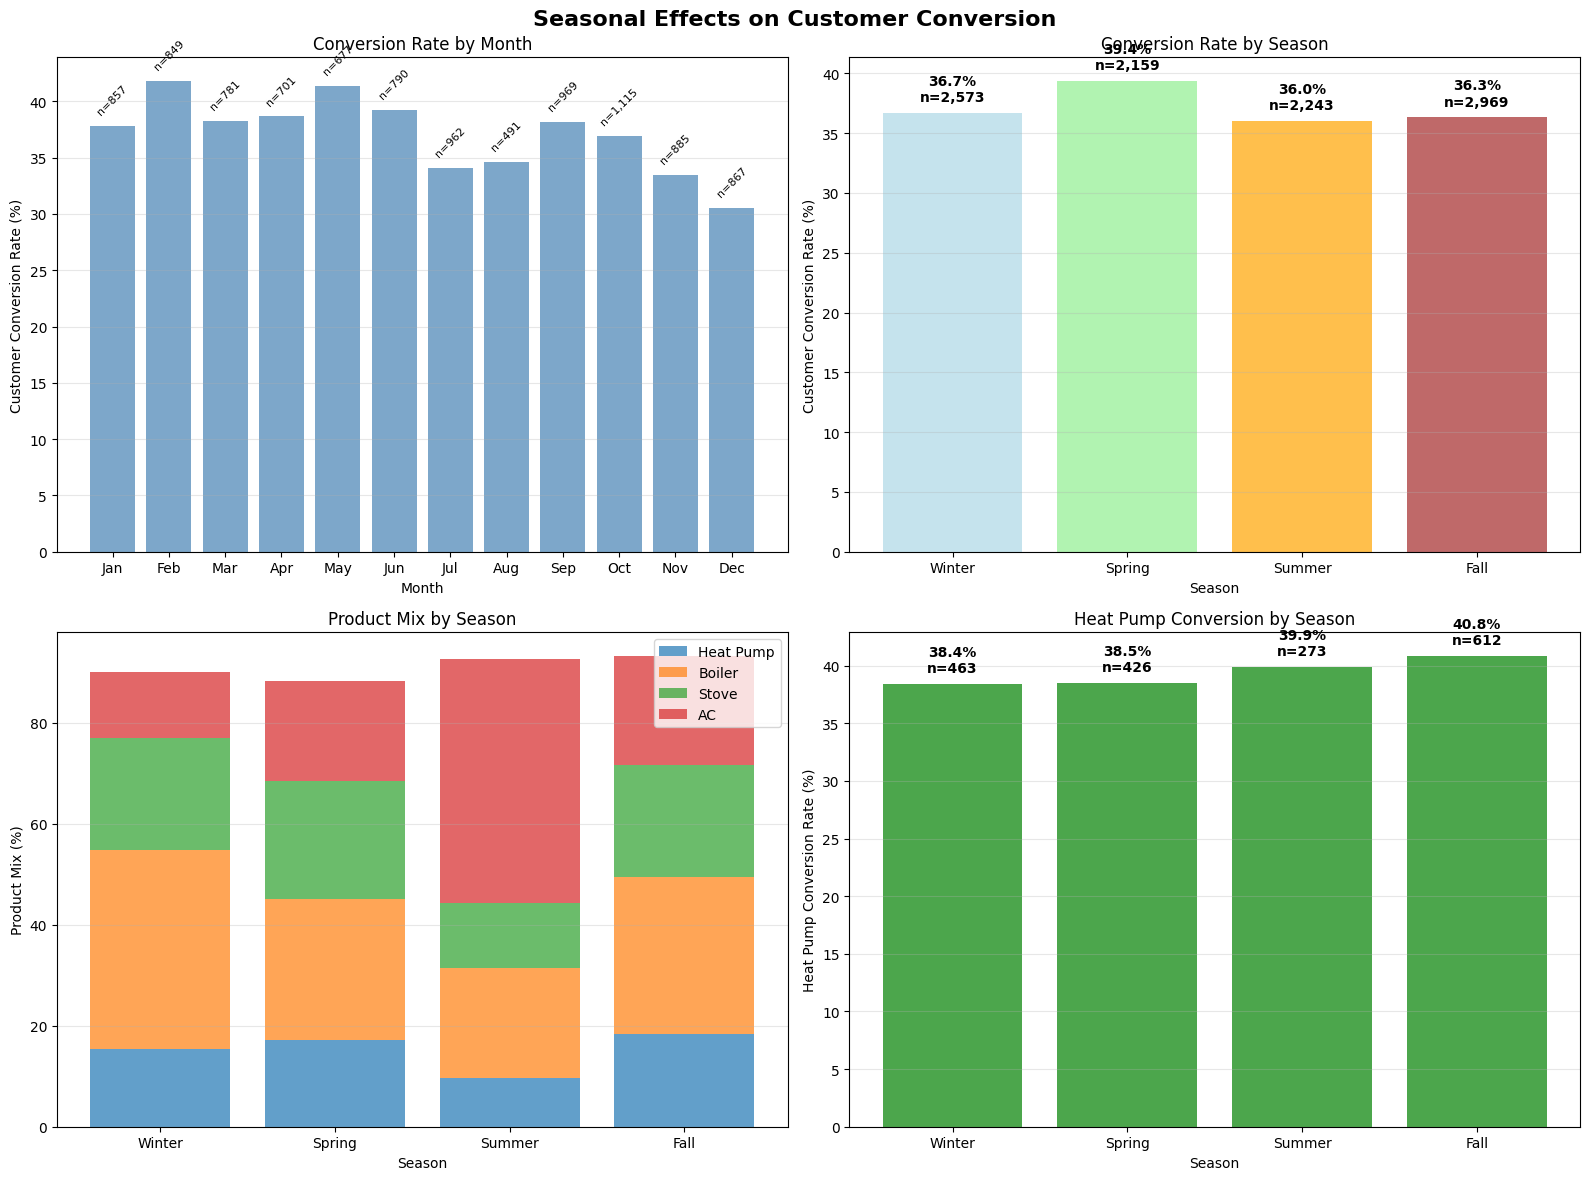


SEASONAL STATISTICS

Conversion by season:
  Winter: 36.7% (n=2,573)
  Spring: 39.4% (n=2,159)
  Summer: 36.0% (n=2,243)
  Fall: 36.3% (n=2,969)

Seasonality chi-square p-value: 0.0773
Statistically significant: NO

Regional Seasonal Pattern

Analyzing 9,602 customers
Price range: €1,332 to €27,121
Median price: €6,191

Top regions: ['Normandie', 'Auvergne-Rhône-Alpes', 'Hauts-de-France']


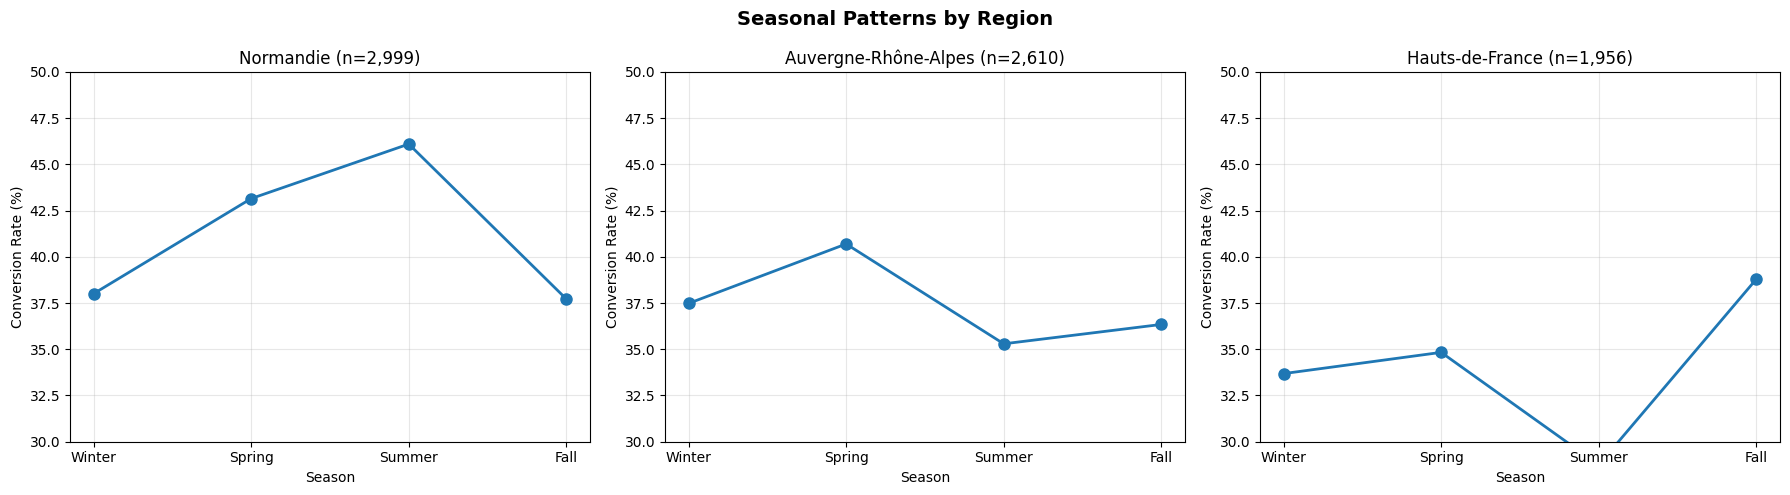


Year-over-year trends

Analyzing 9,602 customers
Price range: €1,332 to €27,121
Median price: €6,191

Quarterly conversion rates:
                  mean  count
year_quarter                 
2025Q1        0.395572   2394
2025Q2        0.398852   2091
2025Q3        0.358942   2343
2025Q4        0.338861   2774


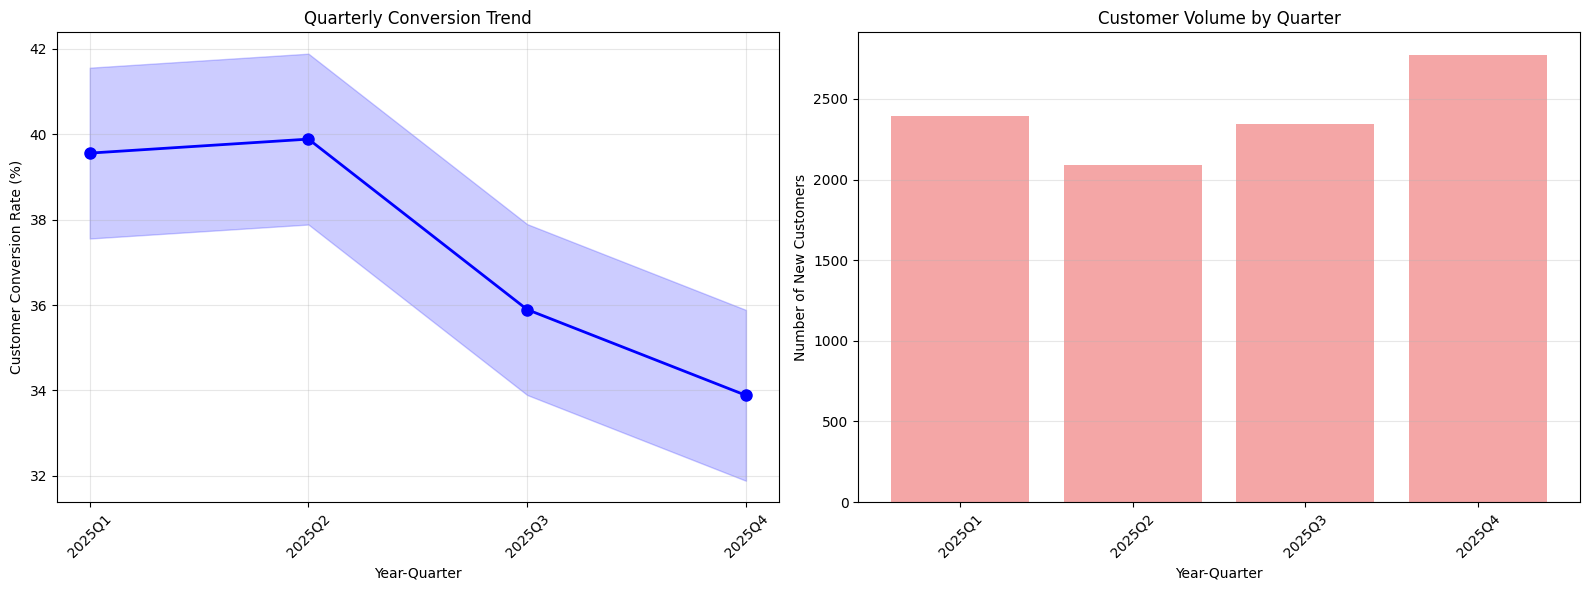


Best and Worst Months Report

Analyzing 9,602 customers
Price range: €1,332 to €27,121
Median price: €6,191

Conversion during subsidy suspensions:
                       mean  count
Normal Periods     0.374845   7259
During Suspension  0.358942   2343

Suspension impact p-value: 0.1735
Statistically significant: NO

Best month: 2 (42.4%, n=816)
Worst month: 12 (30.8%, n=842)

Best season: Spring (39.5%)
Worst season: Fall (36.1%)

Heat pump conversion by season:
  Winter: 39.6%
  Spring: 39.5%
  Summer: 42.0%
  Fall: 41.4%

Analyzing 9,602 customers
Price range: €1,332 to €27,121
Median price: €6,191


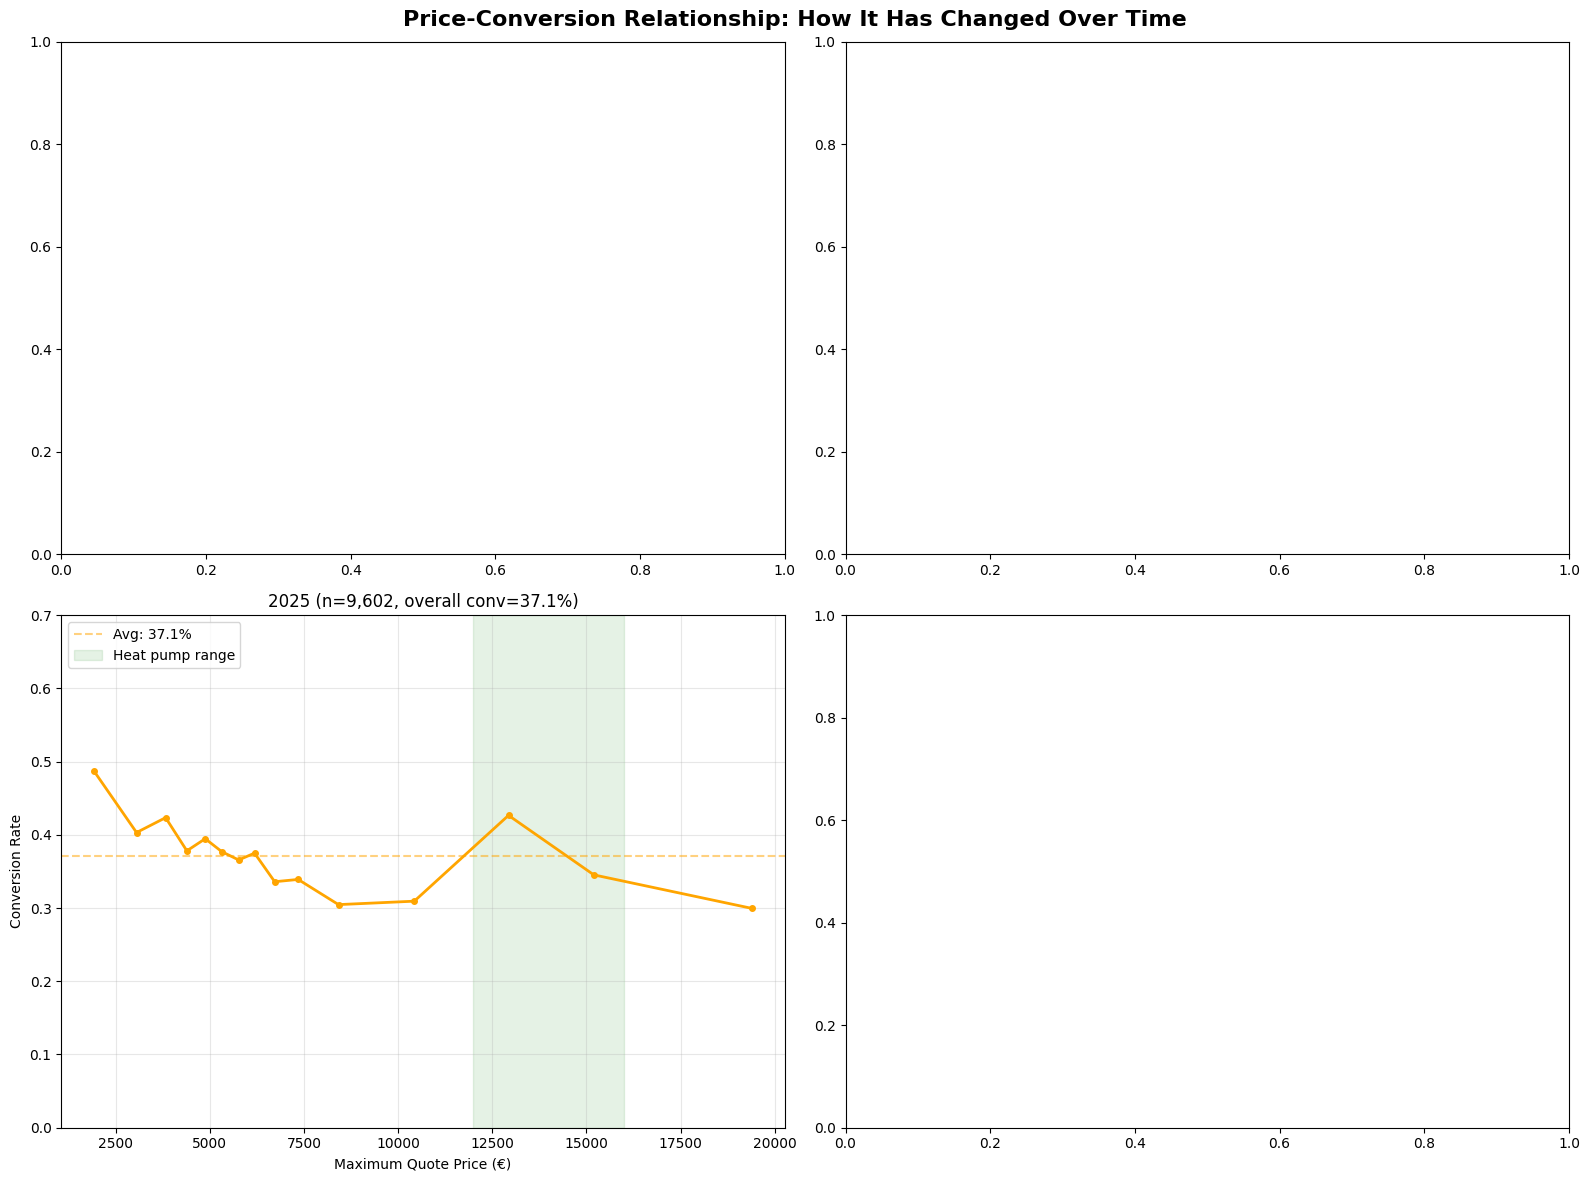


Analyzing 9,602 customers
Price range: €1,332 to €27,121
Median price: €6,191


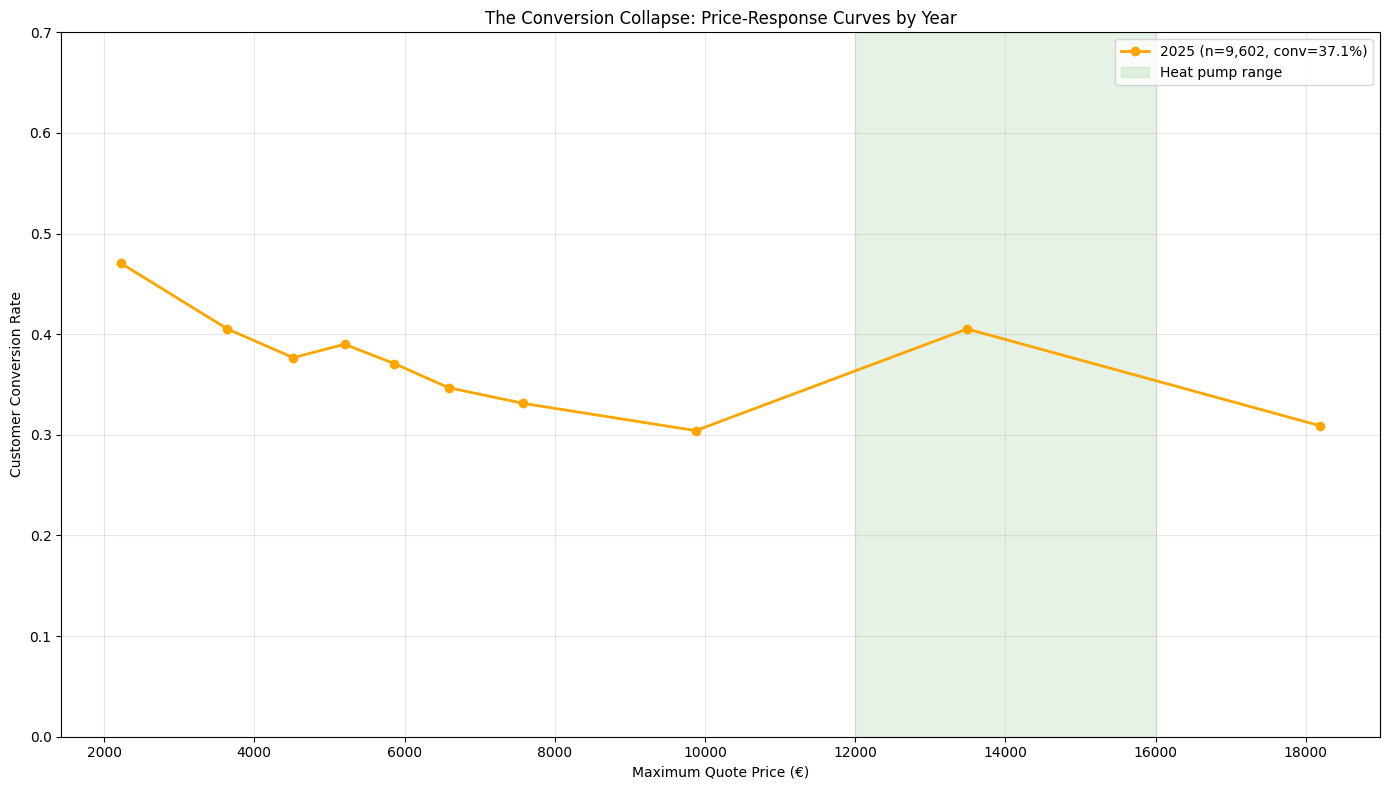


Sweet Spot Analysis Over Time

Analyzing 9,602 customers
Price range: €1,332 to €27,121
Median price: €6,191

Sweet spots by year (price points with conversion > avg + 3%):

2025 (overall avg: 37.1%):
  €1,758: 50.9% (n=481)
  €2,698: 43.1% (n=480)
  €3,902: 43.1% (n=480)
  €5,036: 41.9% (n=480)
  €12,663: 43.3% (n=480)


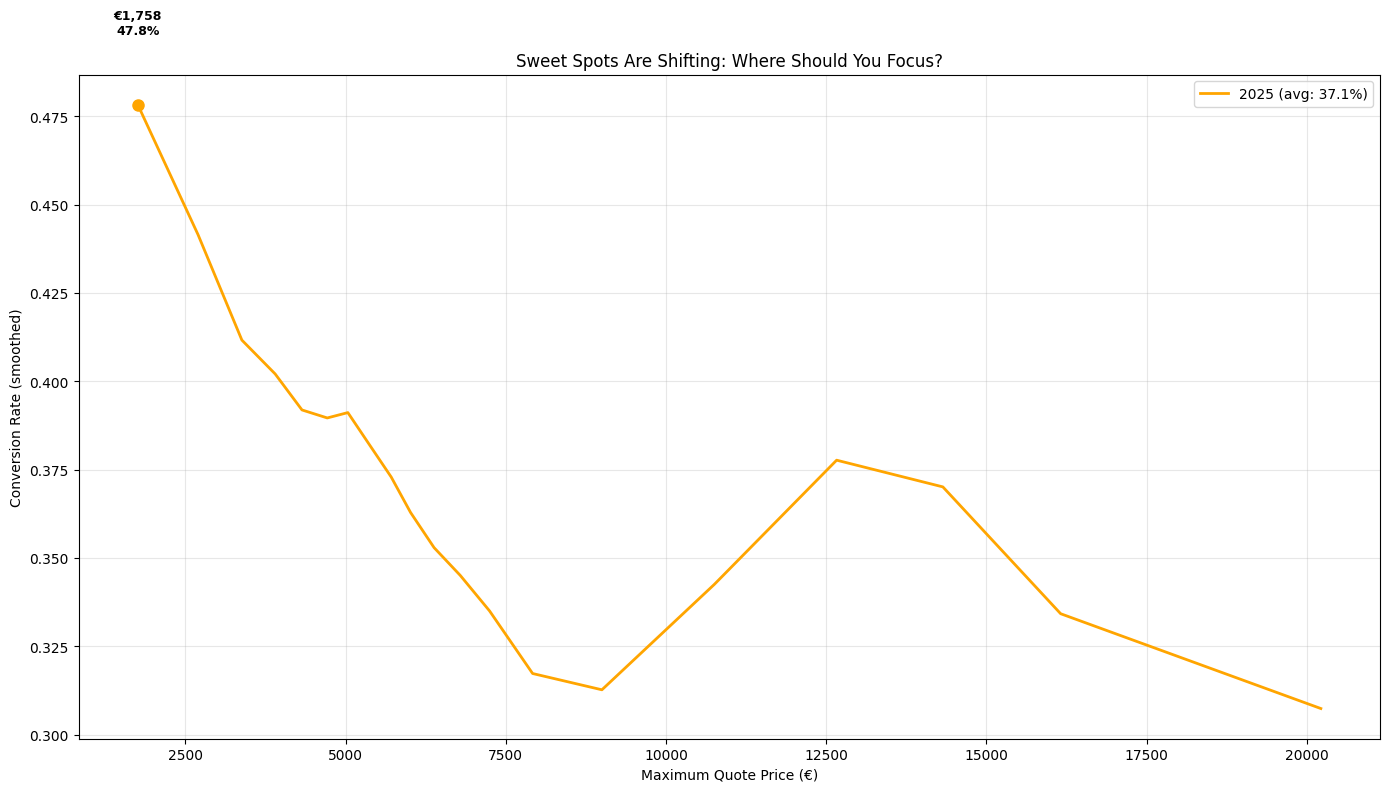


Administrative Uncertainty Effect

Analyzing 9,602 customers
Price range: €1,332 to €27,121
Median price: €6,191

Decision time distribution:
count    9602.000000
mean        7.459175
std        30.155039
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max       372.000000
Name: decision_days, dtype: float64

Customers with 1-day decision: 8,206 (85.5%)


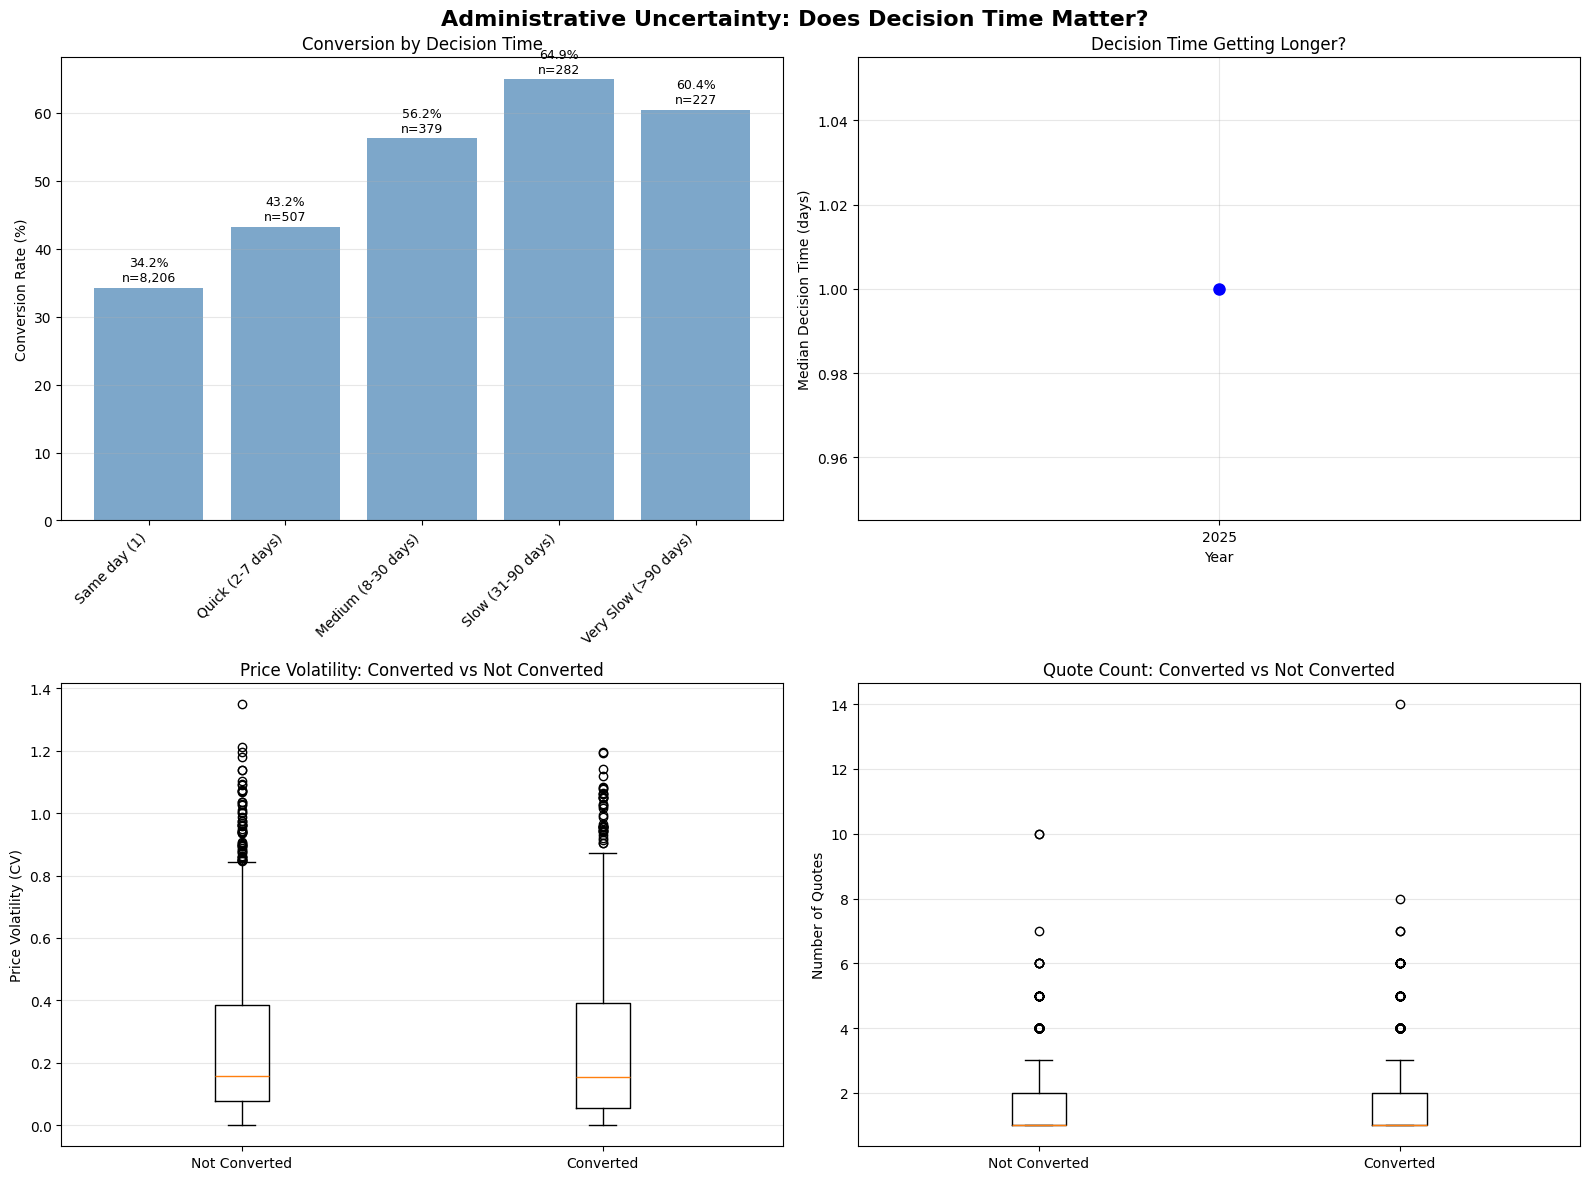


Product Type - Price Conversion Heatmap
Simple pivot table:
price_bin_simple         (1101.459, 4054.72]  (4054.72, 5518.8]  \
main_equipment_category                                           
AC                                 40.902256          31.630170   
Boiler                             48.093842          38.122172   
Heat Pump                          21.428571          77.777778   
Other                              42.829077          22.222222   
Stove                              43.023256          44.264943   
Unknown                            50.000000                NaN   

price_bin_simple         (5518.8, 6997.32]  (6997.32, 11999.94]  \
main_equipment_category                                           
AC                               28.850856            25.914634   
Boiler                           38.325282            36.305732   
Heat Pump                        50.000000            54.347826   
Other                            43.589744            19.047619   


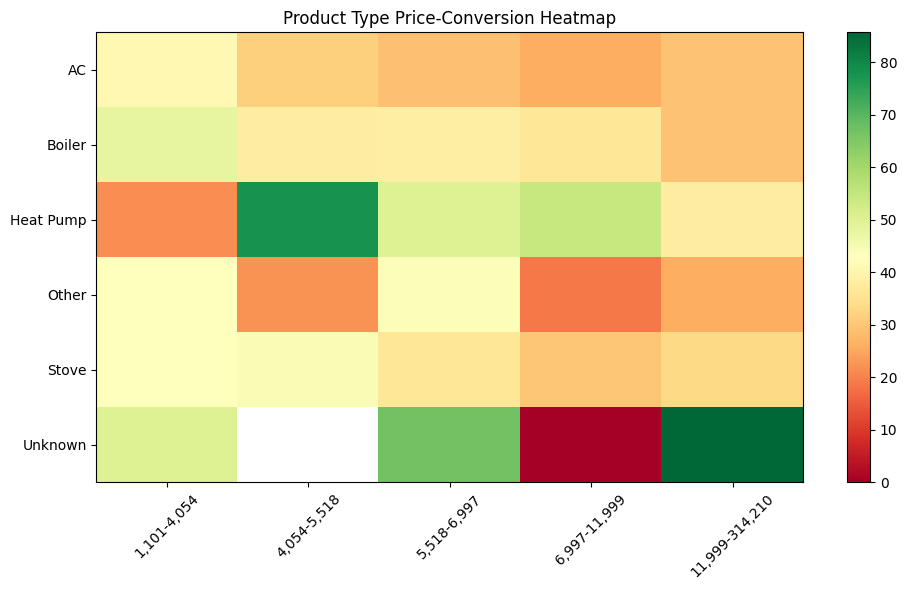


CHECKING MAIN PRODUCT FAMILY
main_product_family
Chaudière                           3065
Climatisation                       2438
Poêle                               2027
Pompe à chaleur                     1362
ECS : Chauffe-eau ou adoucisseur     471
Photovoltaïque                       216
Appareil hybride                     122
Autres                                79
Plomberie Sanitaire                   57
Emetteur de chauffage  ou chappe      47
Produit VMC                           37
Unknown                               16
Fumisterie                             7
Name: count, dtype: int64

Analyzing 9,602 customers
Price range: €1,332 to €27,121
Median price: €6,191


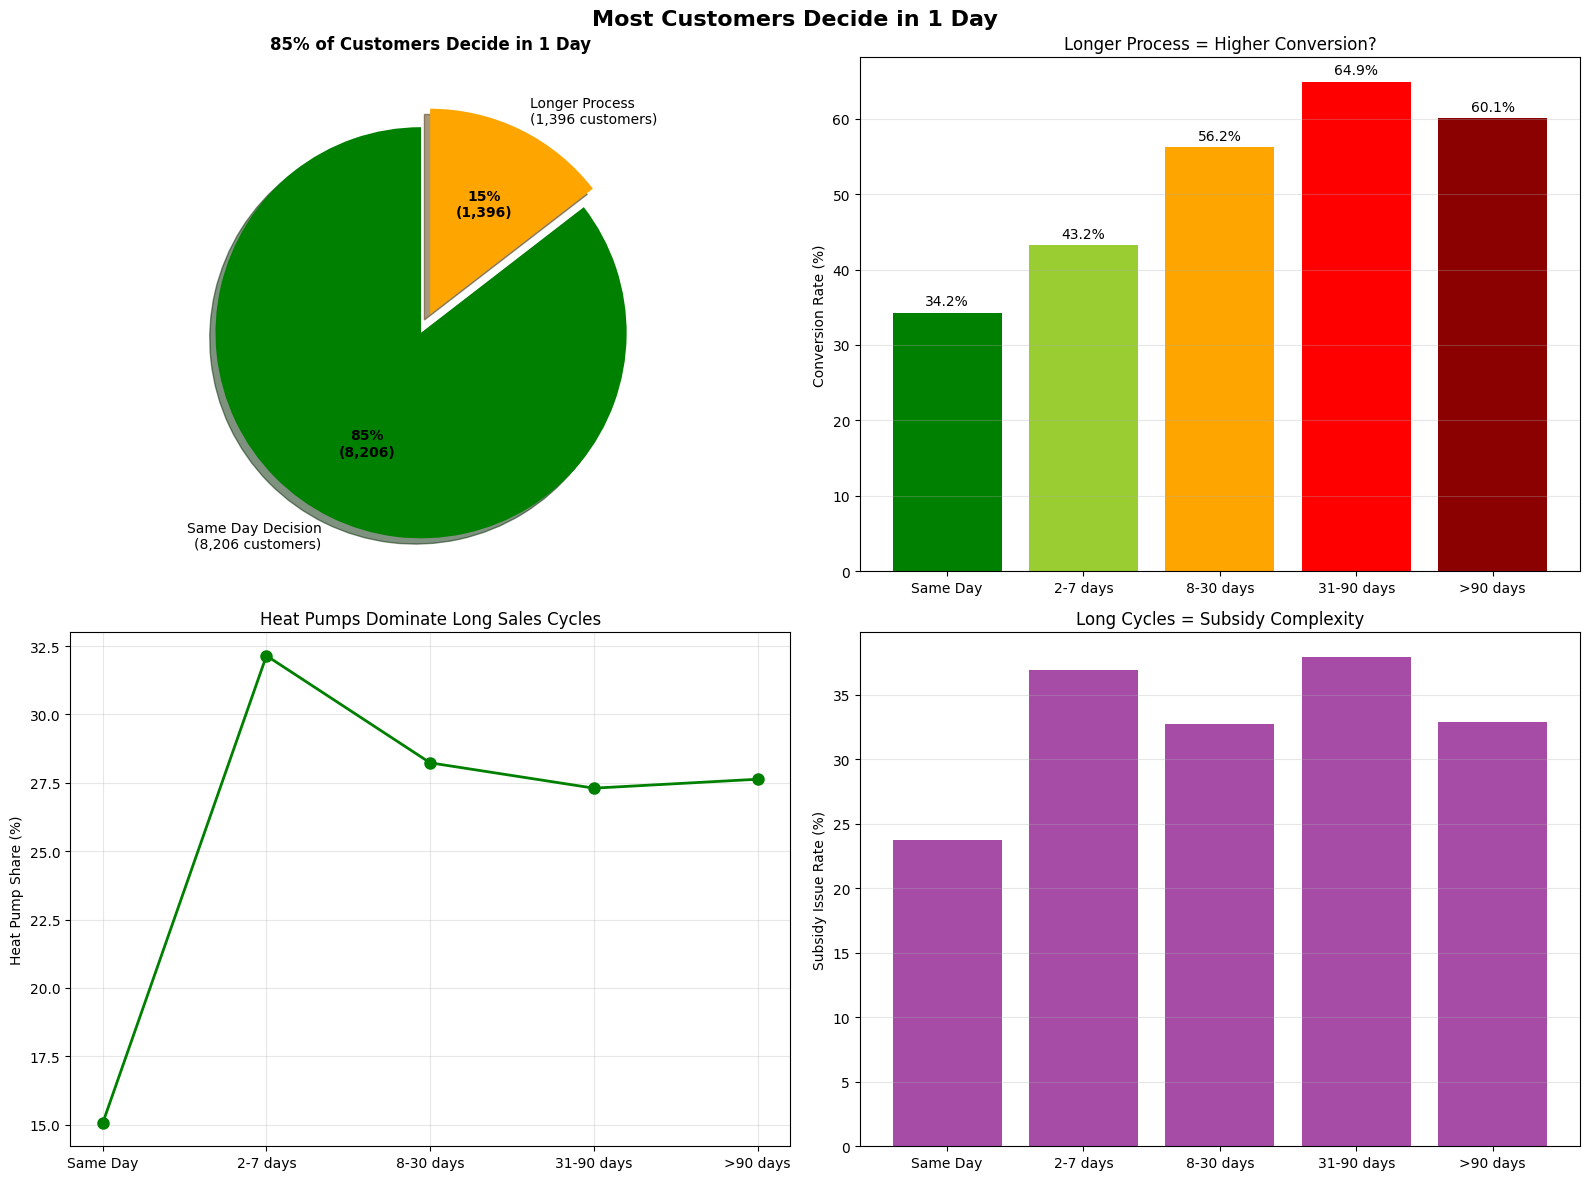


Heat Pump Performance Over Time

Analyzing 9,602 customers
Price range: €1,332 to €27,121
Median price: €6,191

Heat pump customers by year:
        conversion_rate  customer_count  avg_price  subsidy_issue_rate
period                                                                
2025              0.406            1646  15068.636               0.755


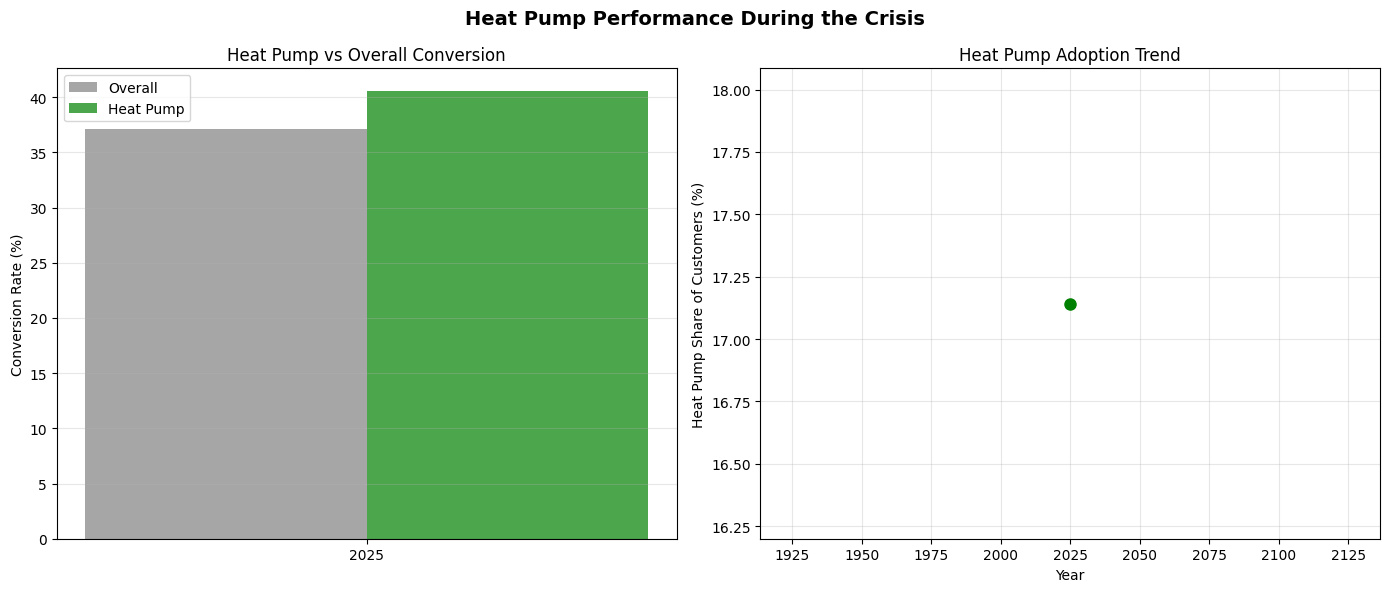


Analyzing 9,602 customers
Price range: €1,332 to €27,121
Median price: €6,191

DYNAMIC INSIGHTS CALCULATED:
Sweet spots: €1.6k (51.7%) and €4.0k (49.1%)
Dead zone: €18.5k-27.1k (29-33%)
Heat pumps: 75% subsidy issues, 40.6% conversion
Price sensitivity: Heat Pump (21.5pts) > Boiler (14.0pts) > Stove (13.9pts) > AC (12.9pts)
Same day decisions: 85%


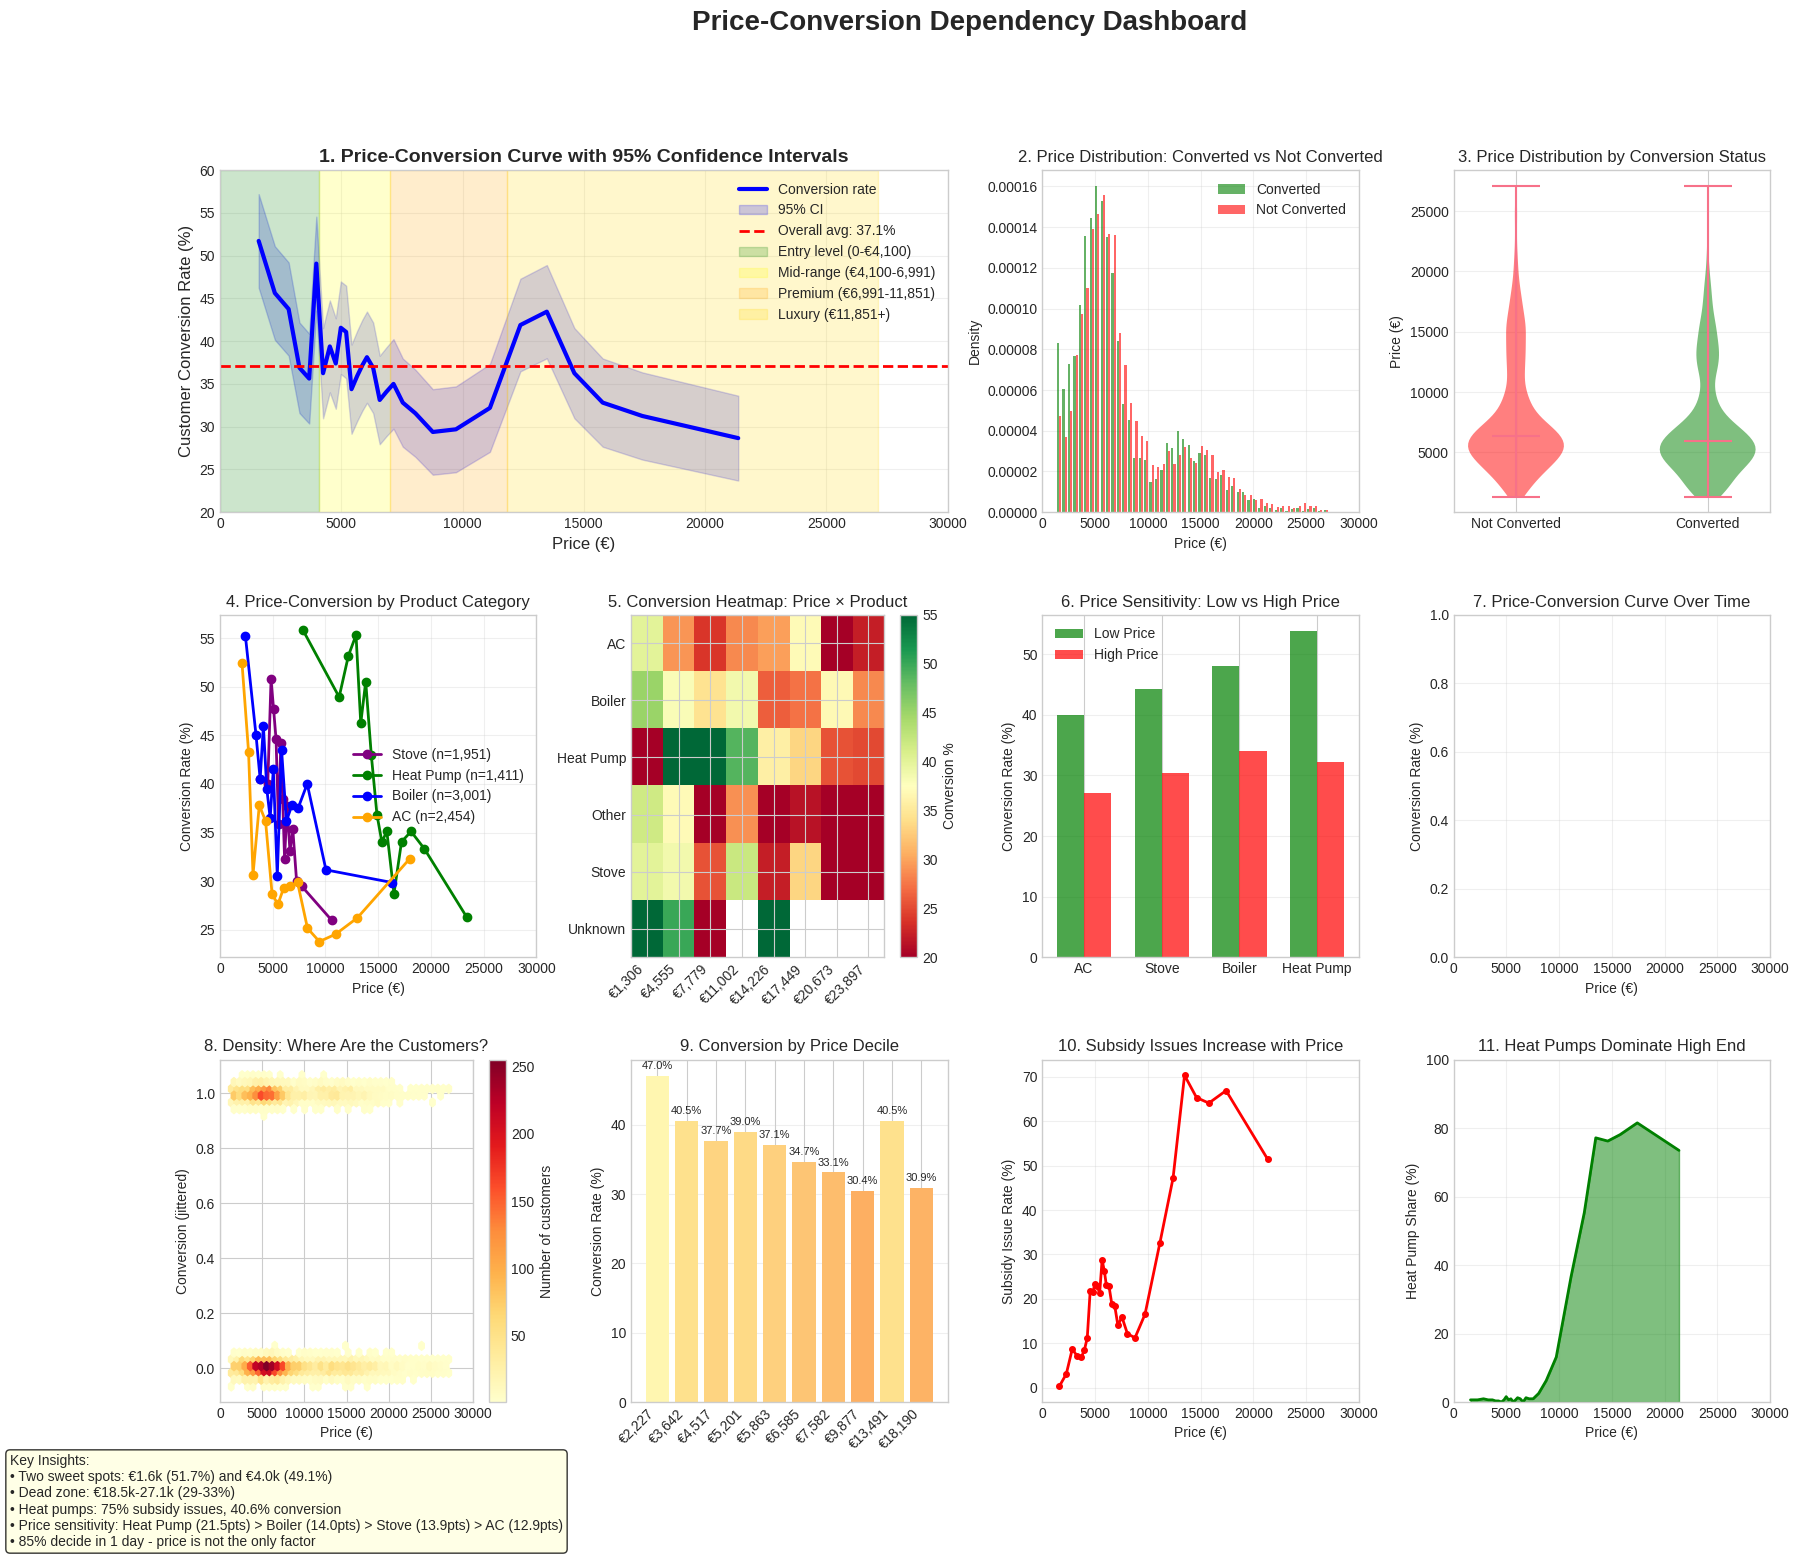

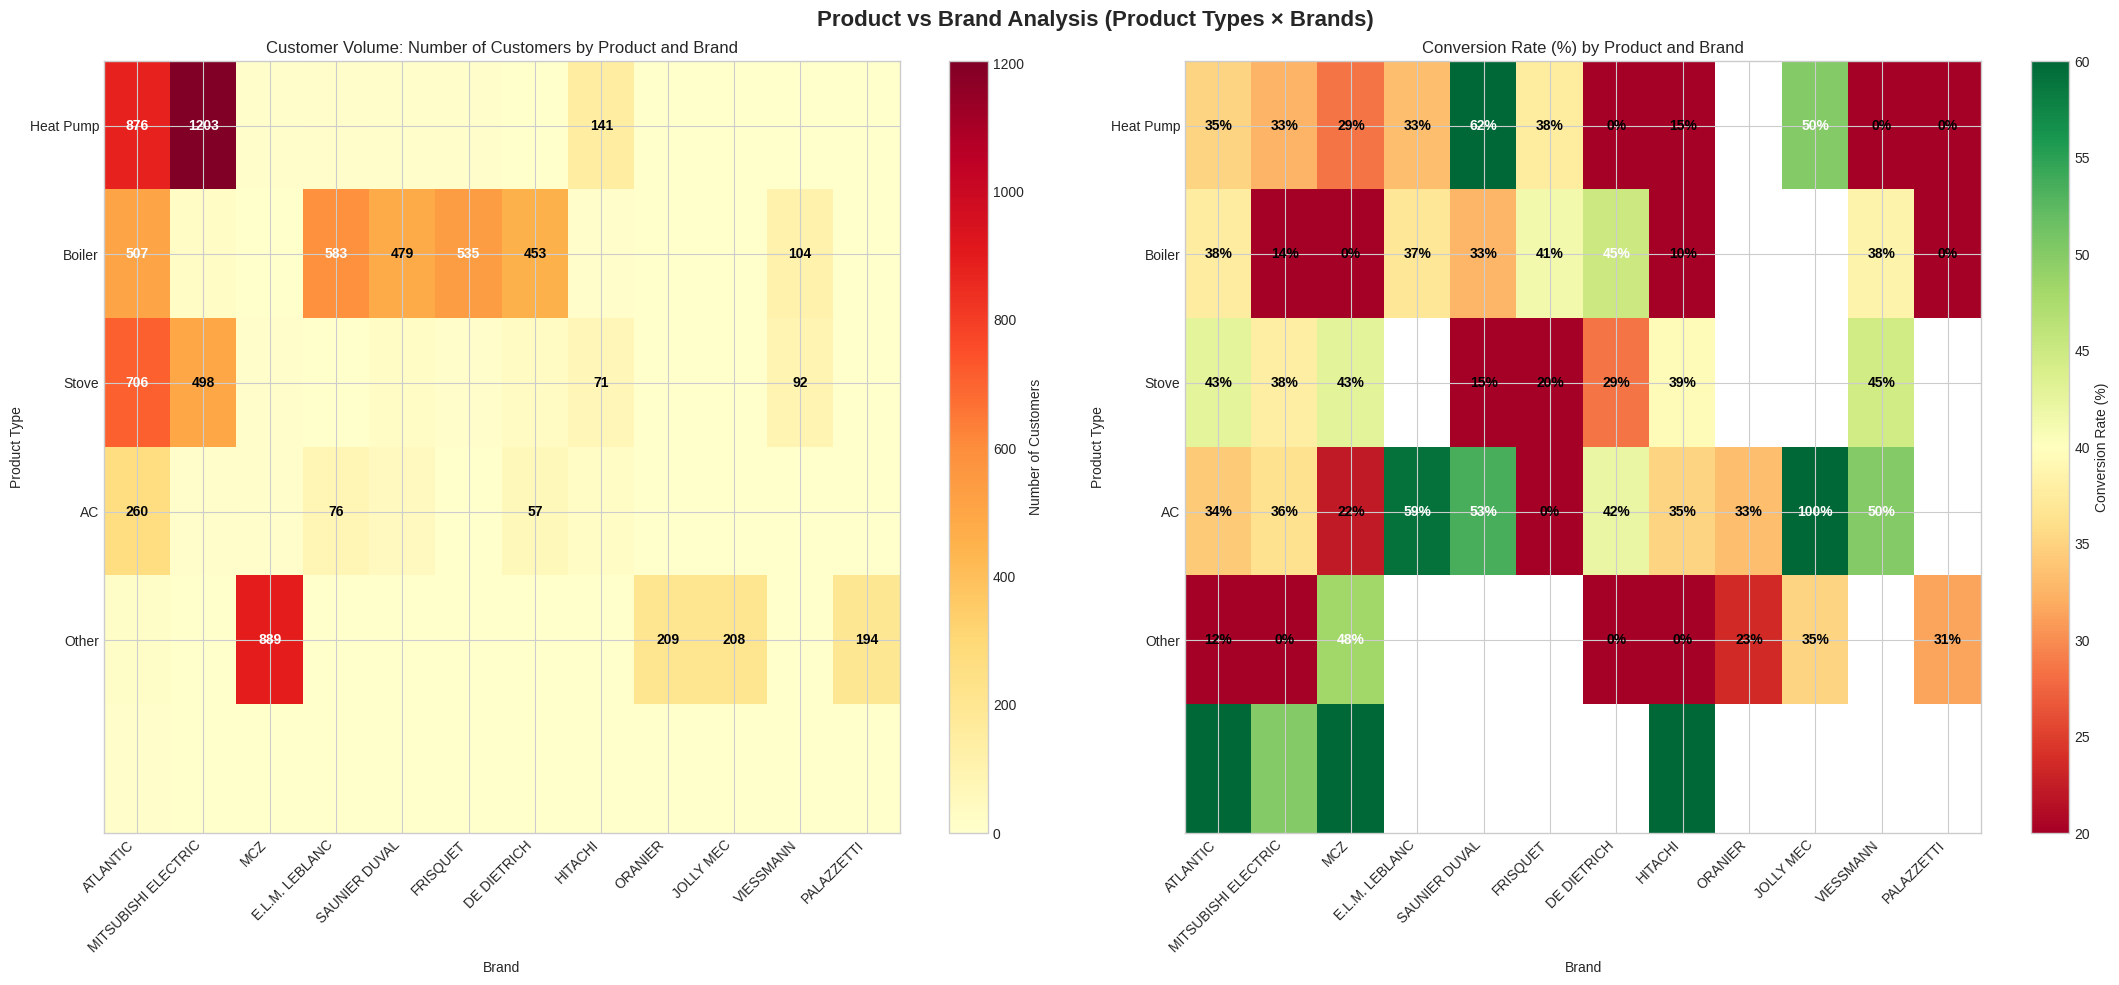


PRODUCT × BRAND ANALYSIS

📊 CUSTOMER VOLUME (Number of Customers):
--------------------------------------------------------------------------------
main_brand               ATLANTIC  MITSUBISHI ELECTRIC  MCZ  E.L.M. LEBLANC  SAUNIER DUVAL  FRISQUET  DE DIETRICH  HITACHI  ORANIER  JOLLY MEC  VIESSMANN  PALAZZETTI
main_equipment_category                                                                                                                                              
AC                            876                 1203    7              12              8         8            2      141        0          2          3           1
Boiler                        507                   21    1             583            479       535          453       10        0          0        104           2
Heat Pump                     706                  498   14               0             27        10           35       71        0          0         92           0
Other                

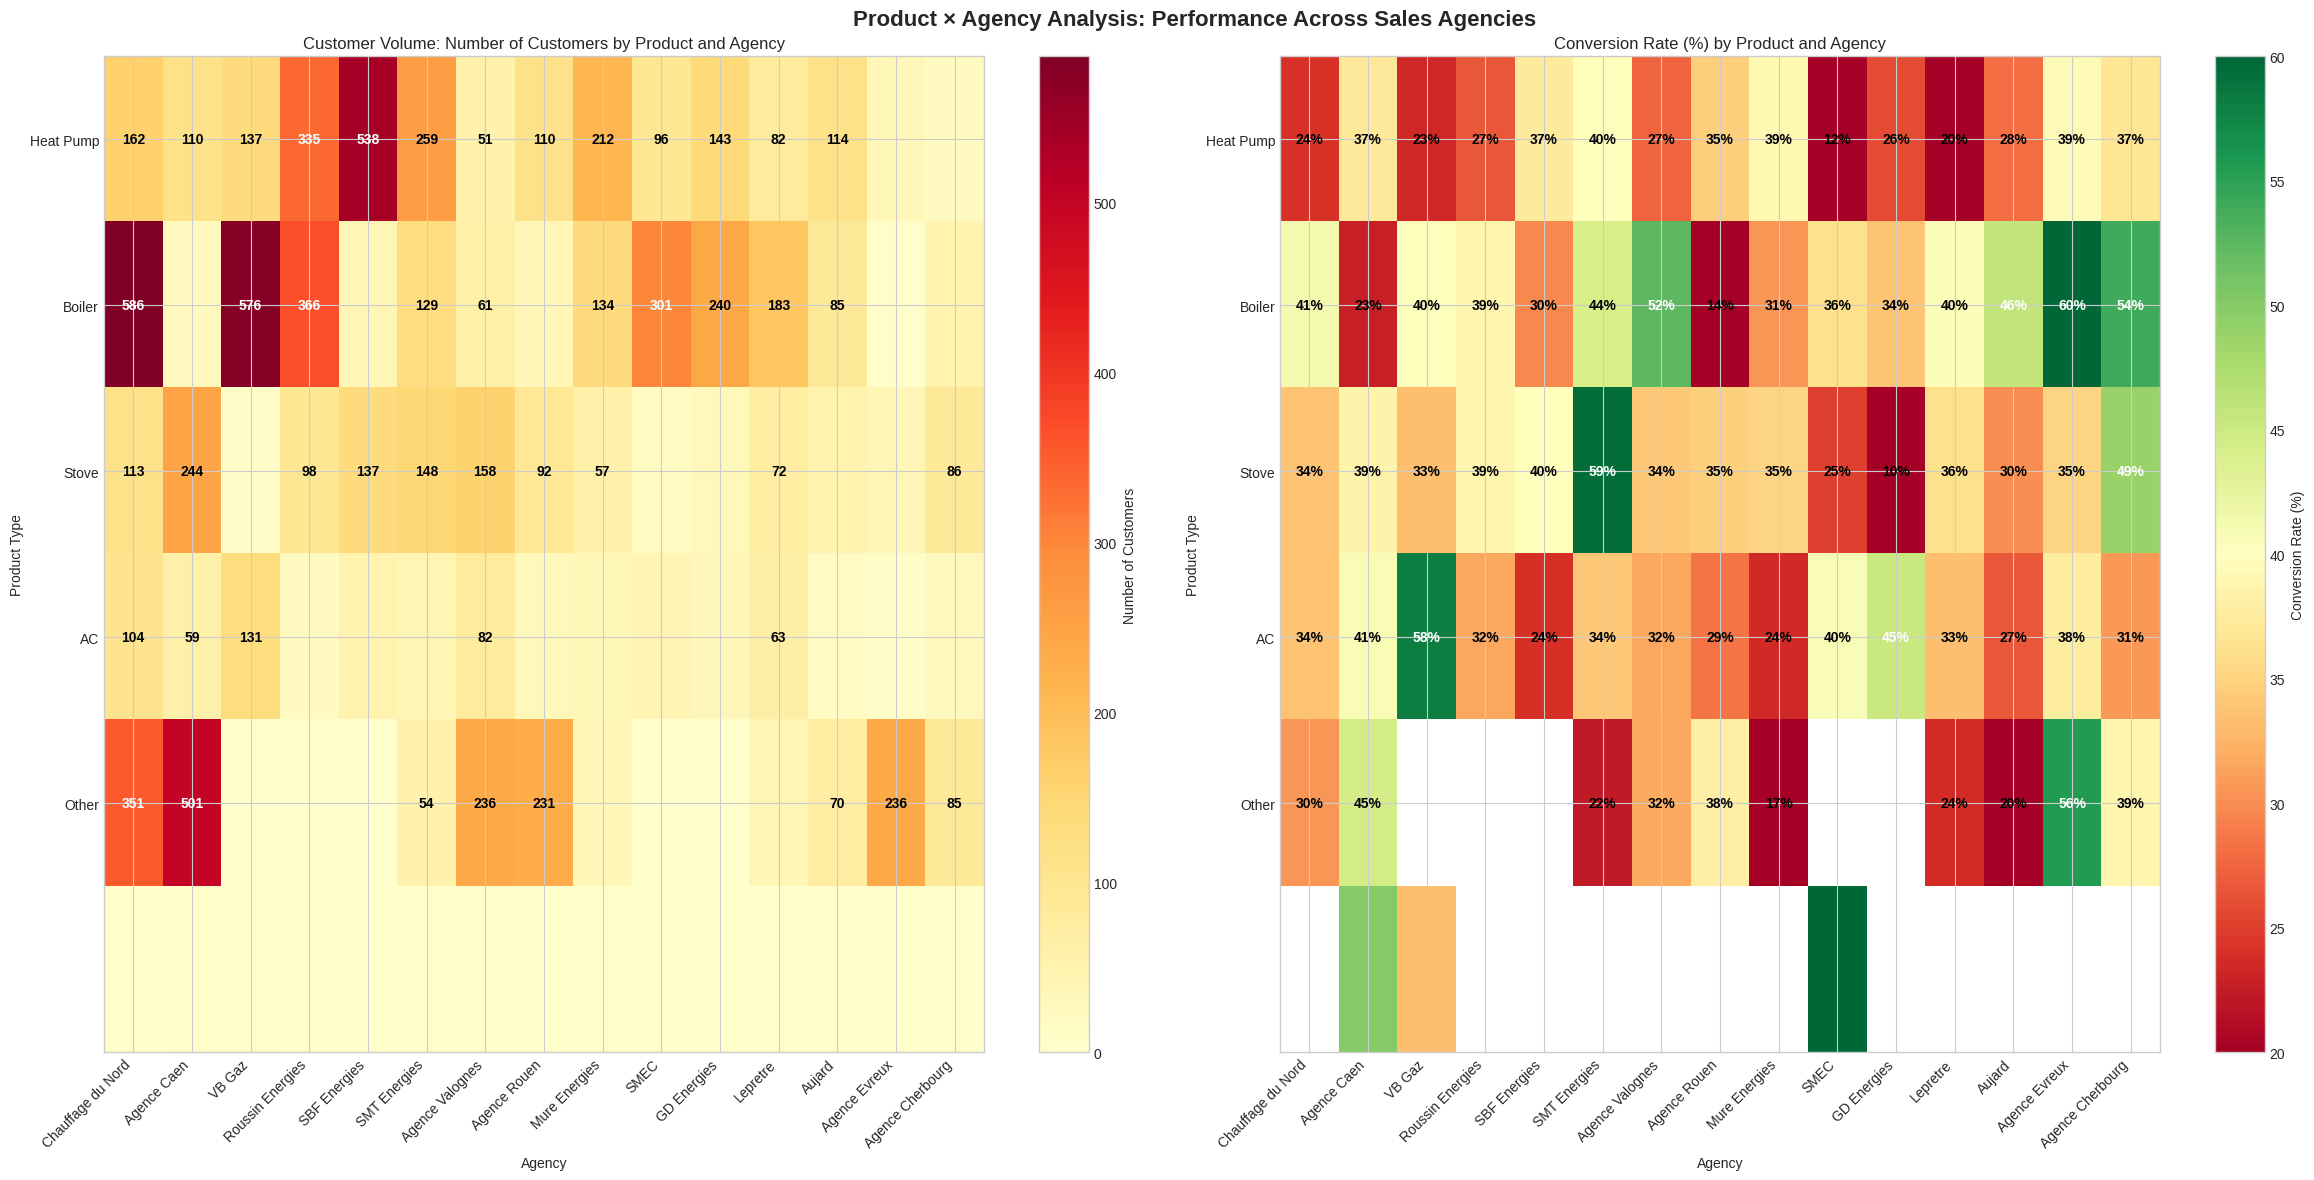


PRODUCT × AGENCY ANALYSIS

📊 CUSTOMER VOLUME BY PRODUCT AND AGENCY:
----------------------------------------------------------------------------------------------------
main_agency              Chauffage du Nord  Agence Caen  VB Gaz  Roussin Energies  SBF Energies  SMT Energies  Agence Valognes  Agence Rouen  Mure Energies  SMEC  GD Energies  Lepretre  Aujard  Agence Evreux  Agence Cherbourg
main_equipment_category                                                                                                                                                                                                          
AC                                     162          110     137               335           538           259               51           110            212    96          143        82     114             33                19
Boiler                                 586           22     576               366            37           129               61            36            

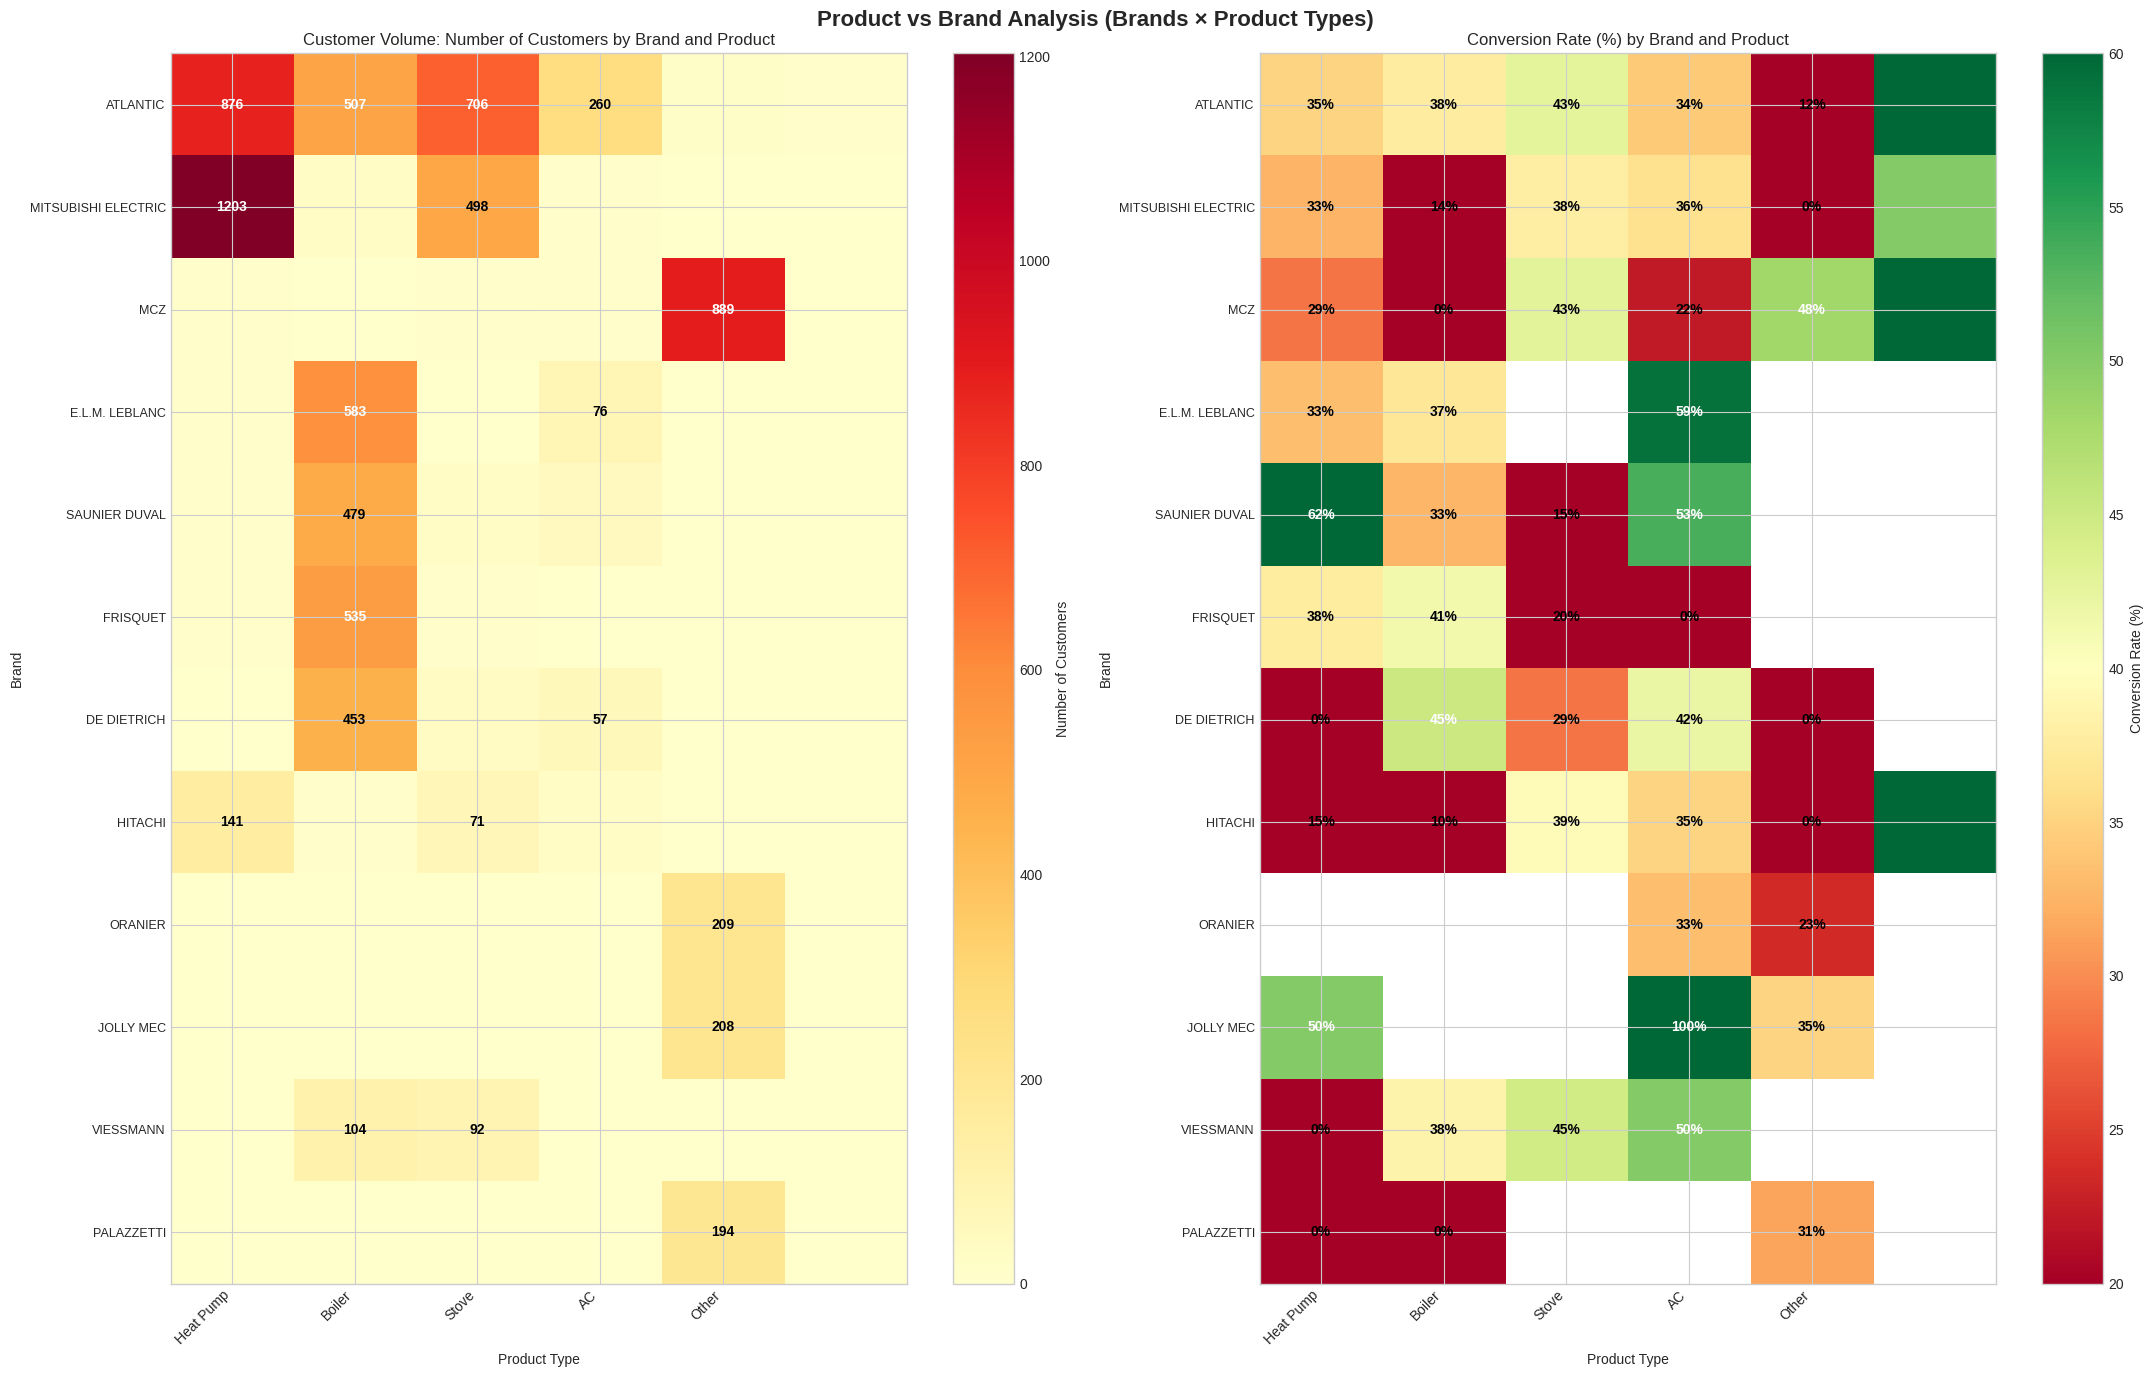


BRAND × PRODUCT ANALYSIS (Swapped Axes)

📊 CUSTOMER VOLUME (Number of Customers):
--------------------------------------------------------------------------------
main_equipment_category    AC  Boiler  Heat Pump  Other  Stove  Unknown
main_brand                                                             
ATLANTIC                  876     507        706    260     16        9
MITSUBISHI ELECTRIC      1203      21        498     11      4        2
MCZ                         7       1         14      9    889        1
E.L.M. LEBLANC             12     583          0     76      0        0
SAUNIER DUVAL               8     479         27     43      0        0
FRISQUET                    8     535         10      1      0        0
DE DIETRICH                 2     453         35     57      1        0
HITACHI                   141      10         71     20      1        1
ORANIER                     0       0          0      3    209        0
JOLLY MEC                   2       0       

(main_equipment_category    AC  Boiler  Heat Pump  Other  Stove  Unknown
 main_brand                                                             
 ATLANTIC                  876     507        706    260     16        9
 MITSUBISHI ELECTRIC      1203      21        498     11      4        2
 MCZ                         7       1         14      9    889        1
 E.L.M. LEBLANC             12     583          0     76      0        0
 SAUNIER DUVAL               8     479         27     43      0        0
 FRISQUET                    8     535         10      1      0        0
 DE DIETRICH                 2     453         35     57      1        0
 HITACHI                   141      10         71     20      1        1
 ORANIER                     0       0          0      3    209        0
 JOLLY MEC                   2       0          0      1    208        0
 VIESSMANN                   3     104         92      2      0        0
 PALAZZETTI                  1       2          0  

In [6]:
conv_no_issue, conv_with_issue = report_customer_conversion_by_subsidy_issue_status(customers)
report_customer_metrics_by_subsidy_issue_status(customers)
visualize_conversion_by_subsidy_issues(customers, conv_no_issue, conv_with_issue)
visualize_policy_suspension_impact(customers, price_var='max_out_of_pocket')

top_products, no_issue_pct, issue_pct = report_customer_subsidy_issues_by_product(customers)
visualize_customer_subsidy_issues_by_product(customers, top_products, no_issue_pct, issue_pct)

visualize_conversion_by_price_sweet_spots(customers, price_var='max_out_of_pocket')
visualize_conversion_by_price_sweet_spots_variant(customers, price_var='max_out_of_pocket')
report_product_conversion_by_price_quartile(customers)
visualize_conversion_by_equipment_category_price(customers, price_var='max_out_of_pocket')
visualise_conversion_by_brand_price(customers, price_var='max_out_of_pocket')
show_two_panel_conversion_by_brand_price(customers, price_var='max_out_of_pocket')
visualize_conversion_by_equipment_type_brand_price(customers, price_var='max_out_of_pocket')

visualize_conversion_by_season(customers, price_var='max_out_of_pocket')
visualize_regional_seasonality(customers, price_var='max_out_of_pocket')

visualize_conversion_by_year(customers, price_var='max_out_of_pocket')
report_best_and_worst_months(customers, price_var='max_out_of_pocket')
show_conversion_by_price_over_time(customers, price_var='max_out_of_pocket')
overlay_all_years_on_one_plot(customers, price_var='max_out_of_pocket')
visualize_conversion_by_prices_sweet_spot_shift(customers, price_var='max_out_of_pocket')
visualize_decision_times(customers, price_var='max_out_of_pocket')
show_product_type_price_conversion_heatmap(customers, price_var='max_out_of_pocket')
show_decision_time_dashboard(customers, price_var='max_out_of_pocket')

visualise_heat_pump_performance(customers, price_var='max_out_of_pocket')

show_conversion_by_price_dashboard(customers, price_var='max_out_of_pocket')

show_product_type_by_brand_heatmap(customers)
show_product_type_by_agency_heatmap(customers)
show_brand_by_product_type_heatmap(customers)

In [7]:
import ipynbname
import subprocess
import os
import sys

def export_notebook_to_pdf(overwrite=True, verbose=True):
    """
    Export current notebook to PDF with overwrite control
    
    Args:
        overwrite (bool): If True, overwrite existing PDF file
        verbose (bool): If True, print progress messages
    
    Returns:
        bool: True if successful, False otherwise
    """
    try:
        # Get notebook path
        notebook_path = ipynbname.path()
        notebook_path_str = str(notebook_path)
        pdf_path = notebook_path_str.replace('.ipynb', '.pdf')
        
        if verbose:
            print(f"📓 Notebook: {notebook_path.name}")
            print(f"📄 PDF path: {pdf_path}")
        
        # Check if PDF exists
        if os.path.exists(pdf_path):
            if overwrite:
                if verbose:
                    print(f"🗑️ Removing existing PDF: {pdf_path}")
                os.remove(pdf_path)
            else:
                if verbose:
                    print(f"⚠️ PDF already exists and overwrite=False")
                return False
        
        # Convert to PDF
        if verbose:
            print("🔄 Converting to PDF...")
        
        result = subprocess.run([
            'jupyter', 'nbconvert', '--to', 'pdf',
            '--no-prompt',  # Suppress input prompts
            notebook_path_str
        ], capture_output=True, text=True)
        
        if result.returncode == 0:
            if verbose:
                print(f"✅ PDF saved: {pdf_path}")
            return True
        else:
            if verbose:
                print(f"❌ Conversion failed:")
                print(result.stderr)
            return False
            
    except Exception as e:
        if verbose:
            print(f"❌ Error: {e}")
        return False

# Use the function
if __name__ == "__main__":
    # Overwrite existing PDF
    export_notebook_to_pdf(overwrite=True)
    
    # Or create new version without overwriting
    # export_notebook_to_pdf(overwrite=False)export_full_notebook_to_pdf()

📓 Notebook: _eda_price_2025.ipynb
📄 PDF path: /home/valeriya/project/homeserve/ai-france-hvac/_eda_price_2025.pdf
🗑️ Removing existing PDF: /home/valeriya/project/homeserve/ai-france-hvac/_eda_price_2025.pdf
🔄 Converting to PDF...
✅ PDF saved: /home/valeriya/project/homeserve/ai-france-hvac/_eda_price_2025.pdf
